# This notebook comes after hyperparameter optimizations!

## Setup

Load libraries:

In [1]:
## General libraries
import os
import yaml
import pickle
import sqlite3
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## ML libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

## Local imports
from snowmodels.utils import compare_multiple_models, ecnoder_preprocessor, load_data, model_variant_selector, load_config

## Set XGBoost device
xgb_device = "cpu"

## Select the Best Encoder

How will this be done? Well, there are a couple of ways to get it done. However, for simplicity, we will count the number of times each encoder returned the best [RMSE](https://www.appliedaicourse.com/blog/root-mean-square-error-rmse/) across all configurations and model. The encoder with the highest count wins!

* Step 1: load all tables in the db

In [2]:
density_db_path='../experiments/optuna_studies.db'

conn = sqlite3.connect(density_db_path)
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]
print("="*19)
print("Tables in database:")
print("="*19, '\n')
for idx, t in enumerate(tables, start=1):
    print(f"({idx}.) {t}")

print('')
print("="*18)
print("Viewing all Tables")
print("="*18)

for table in tables:
    print(f"\nPreview of table: {table}")
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    display(df)

Tables in database:

(1.) studies
(2.) version_info
(3.) study_directions
(4.) study_user_attributes
(5.) study_system_attributes
(6.) trials
(7.) trial_user_attributes
(8.) trial_system_attributes
(9.) trial_params
(10.) trial_values
(11.) trial_intermediate_values
(12.) trial_heartbeats
(13.) alembic_version

Viewing all Tables

Preview of table: studies


,study_id,study_name
0,1,lightgbm_main_onehot
1,2,xgboost_main_onehot
2,3,lightgbm_main_target
3,4,xgboost_main_target
4,5,lightgbm_main_catboost



Preview of table: version_info


,version_info_id,schema_version,library_version
0,1,12,4.2.1



Preview of table: study_directions


...

,trial_intermediate_value_id,trial_id,step,intermediate_value,intermediate_value_type
0,1,1,0,0.049820,FINITE
1,2,2,0,0.049599,FINITE
2,3,3,0,0.049790,FINITE
3,4,4,0,0.050051,FINITE
4,5,5,0,0.049740,FINITE



Preview of table: trial_heartbeats


,trial_heartbeat_id,trial_id,heartbeat



Preview of table: alembic_version


,version_num
0,v3.2.0.a


In [3]:
for table in tables:
    print(f"\nPreview of table: {table}")
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5;", conn)
    display(df)


Preview of table: studies


,study_id,study_name
0,1,lightgbm_main_onehot
1,2,xgboost_main_onehot
2,3,lightgbm_main_target
3,4,xgboost_main_target
4,5,lightgbm_main_catboost



Preview of table: version_info


,version_info_id,schema_version,library_version
0,1,12,4.2.1



Preview of table: study_directions


...

,trial_intermediate_value_id,trial_id,step,intermediate_value,intermediate_value_type
0,1,1,0,0.049820,FINITE
1,2,2,0,0.049599,FINITE
2,3,3,0,0.049790,FINITE
3,4,4,0,0.050051,FINITE
4,5,5,0,0.049740,FINITE



Preview of table: trial_heartbeats


,trial_heartbeat_id,trial_id,heartbeat



Preview of table: alembic_version


,version_num
0,v3.2.0.a


## Density Estimation

- Load and Process Data for ML

In [4]:
with open('../data/data_splits.pkl', 'rb') as f:
    raw_data = pickle.load(f)

In [12]:
raw_data=load_data('../data/data_splits.pkl', final_eval=False) # we set final eval to true to combine train and tune/val sets
main_config = model_variant_selector(variant='main', data=raw_data) # set variant to main
all_config = load_config(config_path='../experiments/hyperparameters.yaml') # loading all config just for the global config

processed_data_cat_main=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=main_config
)

# extract train and test sets 
X_train_main = processed_data_cat_main.x_train
X_test_main = processed_data_cat_main.x_val
y_train = processed_data_cat_main.y_train
y_test = processed_data_cat_main.y_val

### Training the ML Models

- ExtraTrees

Note that only the best config will uploaded on GitHub. However, all configs from the hyperparameter tuning can be found in `../experiments/optuna_studies.db` and `../experiments/optuna_studies_SWE.db`.

In [9]:
with open('../experiments/results/tune_new/extratrees_main_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

ext_hyp_from_optuna = raw_config['performance']['hyperparameters']

ext_trees_main=ExtraTreesRegressor(**ext_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

ext_trees_main.fit(X_train_main, y_train)
y_pred_ext_main = ext_trees_main.predict(X_test_main)

- Random Forest

In [10]:
with open('../experiments/results/tune_new/rf_main_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

rf_hyp_from_optuna = raw_config['performance']['hyperparameters']


rf_trees_main=RandomForestRegressor(**rf_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

rf_trees_main.fit(X_train_main, y_train)
y_pred_rf_main = rf_trees_main.predict(X_test_main)

- Light Gradient Boosting

In [11]:
with open('../experiments/results/tune_new/lightgbm_main_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_main, label=y_train)

lgbm_main = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_main = lgbm_main.predict(X_test_main)

- XGBoost

In [12]:
with open('../experiments/results/tune_new/xgboost_main_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

sampling_method = "gradient_based" if xgb_device == "cuda" else "uniform"

default_params_xgb = {
    "objective": "reg:squarederror",
    "seed": all_config.global_cfg.seed,
    "tree_method": "hist",
    "device": xgb_device,
    "verbosity": 0,
    "sampling_method": sampling_method
}


xgb_params_from_optuna=raw_config['performance']['hyperparameters']
xgb_params_from_optuna.update(default_params_xgb)

dtrain = xgb.DMatrix(X_train_main, label=y_train)
dtest = xgb.DMatrix(X_test_main)

xgb_main = xgb.train(
    xgb_params_from_optuna,
    dtrain,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'], 
)

y_pred_xgb_main = xgb_main.predict(dtest)

### Adding Climatology (Lag 7)

- Load lag 7 data

In [13]:
climate7d_config = model_variant_selector(variant='climate_7d', data=raw_data)

processed_data_cat_7d=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=climate7d_config
)

## y_train and y_test doesn't change, so no need to re-process
X_train_7d = processed_data_cat_7d.x_train
X_test_7d = processed_data_cat_7d.x_val

- Extra Trees

In [14]:
with open('../experiments/results/tune_new/extratrees_climate_7d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

ext_hyp_from_optuna = raw_config['performance']['hyperparameters']


ext_trees_7=ExtraTreesRegressor(**ext_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

ext_trees_7.fit(X_train_7d, y_train)
y_pred_ext_7 = ext_trees_7.predict(X_test_7d)

- Random Forest

In [15]:
with open('../experiments/results/tune_new/rf_climate_7d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

rf_hyp_from_optuna = raw_config['performance']['hyperparameters']


rf_trees_7=RandomForestRegressor(**rf_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

rf_trees_7.fit(X_train_7d, y_train)
y_pred_rf_7 = rf_trees_7.predict(X_test_7d)

- LightGBM

In [14]:
with open('../experiments/results/tune_new/lightgbm_climate_7d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_7d, label=y_train)
val_data = lgb.Dataset(X_test_7d, label=y_test, reference=train_data)

lgbm_7 = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_7 = lgbm_7.predict(X_test_7d)

In [16]:
root_mean_squared_error(y_pred=y_pred_lgbm_7, y_true=y_test)

0.05147902173168471

In [18]:
with open('../data/data_splits.pkl', 'rb') as f:
    data_splits = pickle.load(f)

In [ ]:
def plot_results(results_df, output_path):
    """
    Create a plot of RMSE vs Lag.
    
    Parameters
    ----------
    results_df : pd.DataFrame
        Results dataframe with lag and rmse columns
    output_path : Path
        Path to save the plot
    """
    logger = logging.getLogger(__name__)
    logger.info("Creating RMSE vs Lag plot")
    
    plt.figure(figsize=(12, 6))
    plt.plot(results_df['lag'], results_df['rmse'], 
             marker='o', linewidth=2, markersize=6, color='#2E86AB')
    
    # Highlight the best lag
    best_idx = results_df['rmse'].idxmin()
    best_lag = results_df.loc[best_idx, 'lag']
    best_rmse = results_df.loc[best_idx, 'rmse']
    
    plt.scatter([best_lag], [best_rmse], 
                color='red', s=200, zorder=5, 
                label=f'Best: Lag {best_lag} (RMSE={best_rmse:.6f})')
    
    plt.xlabel('Lag (days)', fontsize=12, fontweight='bold')
    plt.ylabel('Validation RMSE', fontsize=12, fontweight='bold')
    plt.title('LightGBM Performance Across Different Climate Lags', 
              fontsize=14, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(fontsize=11, loc='best')
    plt.tight_layout()
    
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    logger.info("Plot saved to %s", output_path)
    plt.close()

In [19]:
from sklearn.metrics import root_mean_squared_error as rmse
rmses={}
for j in range(1,31):

    X_train_7d['PRECIPITATION_lag_7d'] = data_splits.X_train[f"PRECIPITATION_lag_{j}d"].values
    X_train_7d['TAVG_lag_7d'] = data_splits.X_train[f"TAVG_lag_{j}d"].values

    train_data = lgb.Dataset(X_train_7d, label=y_train)

    lgbm_7 = lgb.train(
        params_from_optuna,
        train_data,
        num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
    )

    X_test_7d['PRECIPITATION_lag_7d'] = data_splits.X_val[f"PRECIPITATION_lag_{j}d"].values
    X_test_7d['TAVG_lag_7d'] = data_splits.X_val[f"TAVG_lag_{j}d"].values
    
    y_pred_lgbm_7 = lgbm_7.predict(X_test_7d)
    score = rmse(y_true=y_test.values, y_pred=y_pred_lgbm_7)
    rmses[f"lag_{j}d"] = score
    print(f"lag_{j}d = {score}")

lag_1d = 0.05180579882778642
lag_2d = 0.05123061231635941
lag_3d = 0.05110979805495371
lag_4d = 0.051117549901501164
lag_5d = 0.05129712951560574
lag_6d = 0.051399423955858066
lag_7d = 0.05147902173168471
lag_8d = 0.0515469043988189
lag_9d = 0.051613941974080015
lag_10d = 0.05174596535492248
lag_11d = 0.05193965835835399
lag_12d = 0.05201587938611202
lag_13d = 0.0521393523812948
lag_14d = 0.052259387233081066
lag_15d = 0.05215677884053557
lag_16d = 0.052288520323705845
lag_17d = 0.05233969459348032
lag_18d = 0.05243455921502807
lag_19d = 0.052468507829893075
lag_20d = 0.052454218440740705
lag_21d = 0.05243044523099647
lag_22d = 0.052494064651878516
lag_23d = 0.05251265009097551
lag_24d = 0.05240949898622843
lag_25d = 0.05245063388948685
lag_26d = 0.05246524982291513
lag_27d = 0.0523852407223571
lag_28d = 0.052345489384477105
lag_29d = 0.052494982030907494
lag_30d = 0.05237349825963845


In [20]:
import yaml
import re
from pathlib import Path

def create_lags_dict(folder_path):
    """
    Create a dictionary of lag numbers to RMSE values from YAML files.
    
    Parameters:
    -----------
    folder_path : str
        Path to the folder containing the YAML files
        
    Returns:
    --------
    dict
        Dictionary with lag numbers as keys and RMSE values as values
        
    Example:
    --------
    >>> lags = create_lags_dict("path/to/tune_lags_optimization")
    >>> print(lags)
    """
    lags = {}
    
    # Get all YAML files in the folder
    yaml_files = list(Path(folder_path).glob('*.yaml')) + list(Path(folder_path).glob('*.yml'))
    
    for yaml_file in yaml_files:
        filename = yaml_file.name
        
        # Extract lag number from filename
        match = re.search(r'climate_(\d+)d_tune_target', filename)
        if match:
            lag_num = int(match.group(1))
            
            # Extract RMSE from YAML
            with open(yaml_file, 'r') as f:
                data = yaml.safe_load(f)
            rmse = data['performance']['metrics']['rmse']
            
            lags[lag_num] = rmse
    
    # Sort by lag number
    return dict(sorted(lags.items()))

In [21]:
lags = create_lags_dict("/home/habeeb/ml_density/density-models/experiments/results/tune_lags_optimization")
lags

{1: 0.051244753108645645,
 2: 0.05069381657516134,
 3: 0.050556505455302284,
 4: 0.05068133342950961,
 5: 0.05073194952628703,
 6: 0.05071159183916979,
 7: 0.050945065362432464,
 8: 0.05100470181590246,
 9: 0.050947652188068945,
 10: 0.05125422481932094,
 11: 0.05135453333824259,
 12: 0.05130398448891209,
 13: 0.05158698039878172,
 14: 0.051491287031042776,
 15: 0.051596943169981216,
 16: 0.0516310474163712,
 17: 0.051747216366320306,
 18: 0.051833075321084644,
 19: 0.051840795610714675,
 20: 0.05185590431087912,
 21: 0.05179931969406809,
 22: 0.05186519637506128,
 23: 0.05181420282502372,
 24: 0.05179341312540656,
 25: 0.05176925344183419,
 26: 0.05179726213395412,
 27: 0.051790428346868346,
 28: 0.051672784576032915,
 29: 0.05168368857692772,
 30: 0.05167228868038254}

In [24]:
0.0509 - 0.0506

0.00030000000000000165

In [23]:
y

array([0.0512, 0.0507, 0.0506, 0.0507, 0.0507, 0.0507, 0.0509, 0.051 ,
       0.0509, 0.0513, 0.0514, 0.0513, 0.0516, 0.0515, 0.0516, 0.0516,
       0.0517, 0.0518, 0.0518, 0.0519, 0.0518, 0.0519, 0.0518, 0.0518,
       0.0518, 0.0518, 0.0518, 0.0517, 0.0517, 0.0517])

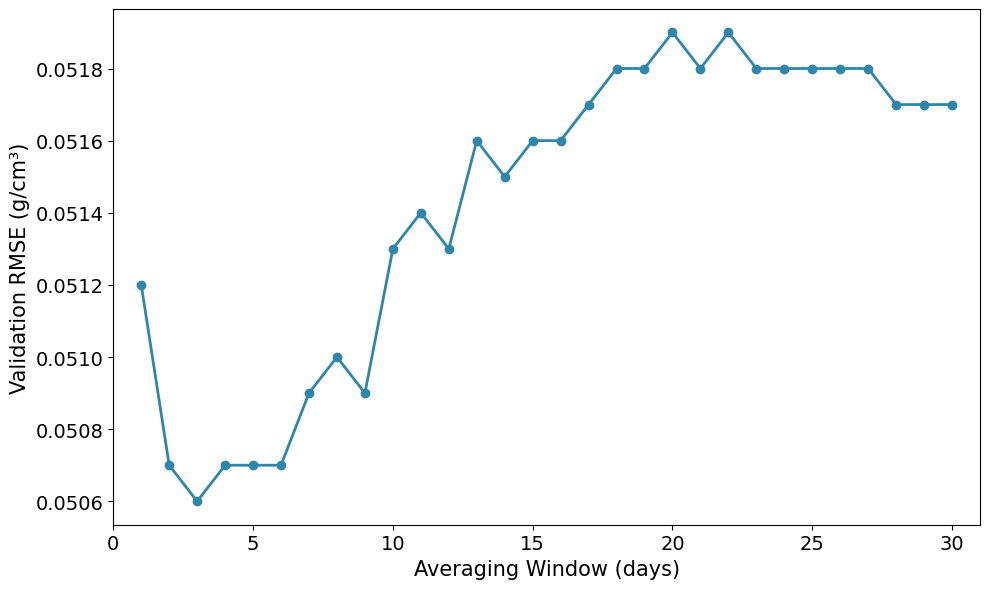

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Your data

x = list(lags.keys())
y = list(lags.values())
y = np.round(y, decimals=4)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'o-', linewidth=2, markersize=6, color='#2E86AB')

# Formatting
ax.set_xlabel('Averaging Window (days)', fontsize=15)
ax.set_ylabel('Validation RMSE (g/cm³)', fontsize=15)
# ax.grid(True, alpha=0.3, linestyle='--')

ax.tick_params(axis='both', which='major', labelsize=14)

# Highlight the near-optimal range (3-10 days)
# ax.axvspan(2, 7, alpha=0.10, color='green', label='Near-optimal range (2-7 days)')
# ax.axvline(x=7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Selected: 7 days (weekly window)')

# # Mark the minimum
# min_lag = min(lags.items(), key=lambda x: x[1])
# ax.plot(min_lag[0], min_lag[1], 'r*', markersize=15, label=f'Minimum: {min_lag[0]} days')

# ax.legend(fontsize=13, loc='lower right')
ax.set_xlim(0, 31)

# Format y-axis with appropriate precision
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.4f}'))

plt.tight_layout()

plt.savefig('../plots/lags_exploration.jpg', dpi=300)
plt.show()

In [2]:
CLIMATE_5_FEATURES = ['PRECIPITATION_lag_5d', 'TAVG_lag_5d']
CLIMATE_6_FEATURES = ['PRECIPITATION_lag_6d', 'TAVG_lag_6d']

print(globals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', "CLIMATE_5_FEATURES = ['PRECIPITATION_lag_5d', 'TAVG_lag_5d']\nCLIMATE_6_FEATURES = ['PRECIPITATION_lag_6d', 'TAVG_lag_6d']", "CLIMATE_5_FEATURES = ['PRECIPITATION_lag_5d', 'TAVG_lag_5d']\nCLIMATE_6_FEATURES = ['PRECIPITATION_lag_6d', 'TAVG_lag_6d']\n\nprint(globals())"], '_oh': {}, '_dh': [PosixPath('/home/habeeb/ml_density/density-models/notebooks')], 'In': ['', "CLIMATE_5_FEATURES = ['PRECIPITATION_lag_5d', 'TAVG_lag_5d']\nCLIMATE_6_FEATURES = ['PRECIPITATION_lag_6d', 'TAVG_lag_6d']", "CLIMATE_5_FEATURES = ['PRECIPITATION_lag_5d', 'TAVG_lag_5d']\nCLIMATE_6_FEATURES = ['PRECIPITATION_lag_6d', 'TAVG_lag_6d']\n\nprint(globals())"], 'Out': {}, 'get_ipython': <bound method InteractiveShell.get_ipython of <ipykernel.zmqshel

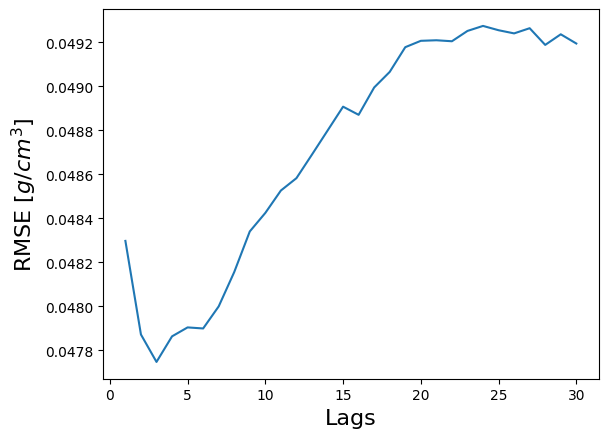

In [21]:
plt.plot(range(1,31), rmses.values())
plt.xlabel("Lags", fontsize=16)
plt.ylabel("RMSE $[g/cm^3]$", fontsize=16)
plt.savefig('../plots/rmse_vs_lags.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
0.047748 + 0.047748*(0.5/100)

0.04798674

In [15]:
0.5/100

0.005

In [14]:
0.0477481 * 0.0005

2.3874050000000002e-05

In [8]:
np.round(y, decimals=3)

array([0.048, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048,
       0.048, 0.048, 0.049, 0.049, 0.049, 0.049, 0.049, 0.049, 0.049,
       0.049, 0.049, 0.049, 0.049, 0.049, 0.049, 0.049, 0.049, 0.049,
       0.049, 0.049, 0.049])

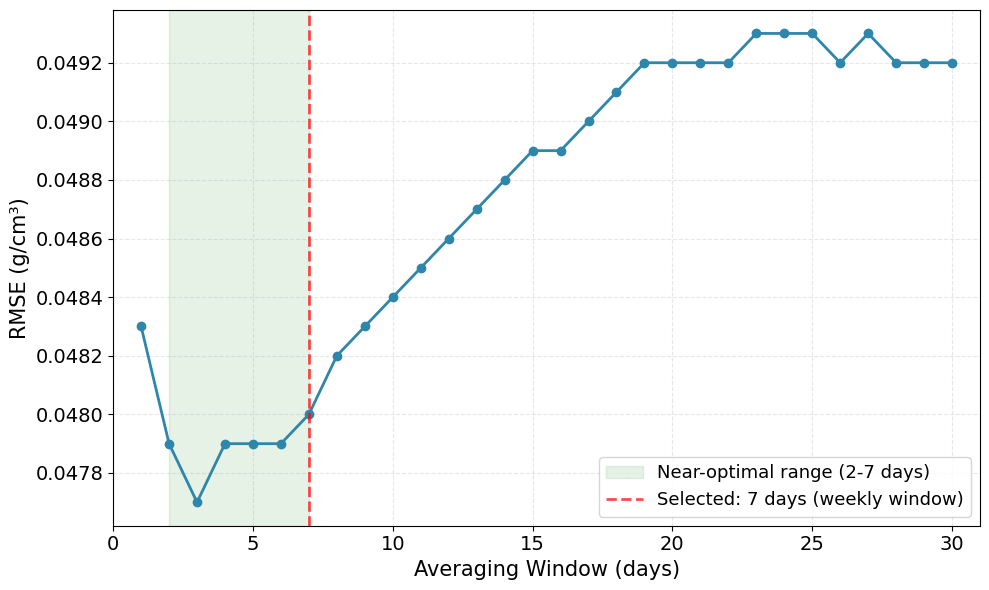

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
lags = {
    1: 0.048297745488371444,
    2: 0.04787259754002946,
    3: 0.04774812464026211,
    4: 0.047864282765987955,
    5: 0.04790486210413014,
    6: 0.047900083188100115,
    7: 0.04800027196648612,
    8: 0.048156373921787336,
    9: 0.048340695241799625,
    10: 0.04842486163302986,
    11: 0.04852654980931676,
    12: 0.048582674667974605,
    13: 0.04868987176840851,
    14: 0.04879853295458548,
    15: 0.04890732798261437,
    16: 0.04887035769664789,
    17: 0.048994558887090055,
    18: 0.04906530934531923,
    19: 0.04917752384584953,
    20: 0.04920641403582388,
    21: 0.04920894345382099,
    22: 0.049204440469635284,
    23: 0.04925130772727027,
    24: 0.049274068000215575,
    25: 0.049254502488469076,
    26: 0.04924014121967456,
    27: 0.04926364824614261,
    28: 0.04918785500081185,
    29: 0.049236040326916336,
    30: 0.04919416728020177
}

x = list(lags.keys())
y = list(lags.values())
y = np.round(y, decimals=4)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'o-', linewidth=2, markersize=6, color='#2E86AB')

# Formatting
ax.set_xlabel('Averaging Window (days)', fontsize=15)
ax.set_ylabel('RMSE (g/cm³)', fontsize=15)
ax.grid(True, alpha=0.3, linestyle='--')

ax.tick_params(axis='both', which='major', labelsize=14)

# Highlight the near-optimal range (3-10 days)
ax.axvspan(2, 7, alpha=0.10, color='green', label='Near-optimal range (2-7 days)')
ax.axvline(x=7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Selected: 7 days (weekly window)')

# # Mark the minimum
# min_lag = min(lags.items(), key=lambda x: x[1])
# ax.plot(min_lag[0], min_lag[1], 'r*', markersize=15, label=f'Minimum: {min_lag[0]} days')

ax.legend(fontsize=13, loc='lower right')
ax.set_xlim(0, 31)

# Format y-axis with appropriate precision
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.4f}'))

plt.tight_layout()

plt.savefig('../plots/lags_exploration.jpg', dpi=300)
plt.show()

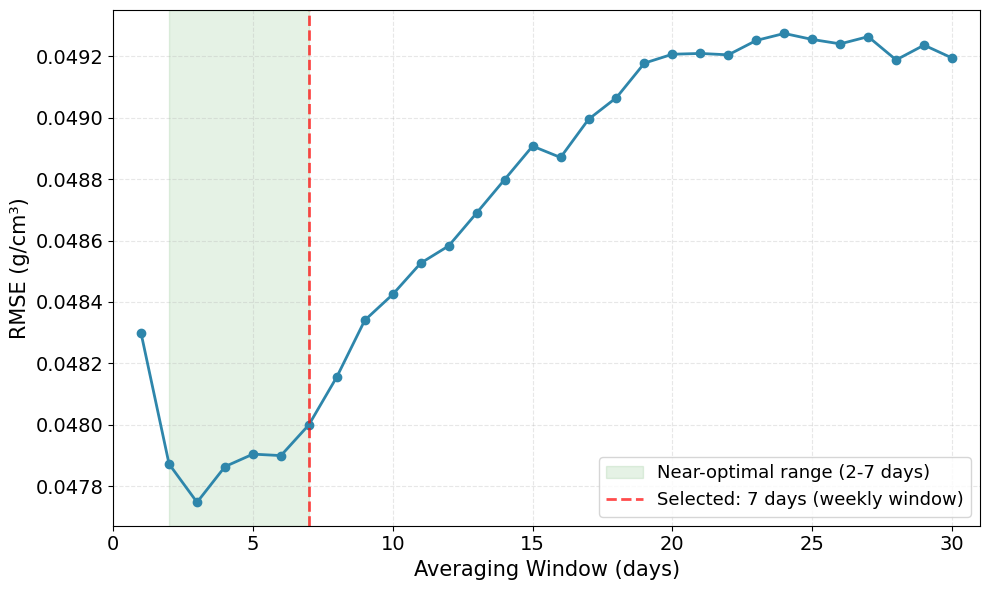

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
lags = {
    1: 0.048297745488371444,
    2: 0.04787259754002946,
    3: 0.04774812464026211,
    4: 0.047864282765987955,
    5: 0.04790486210413014,
    6: 0.047900083188100115,
    7: 0.04800027196648612,
    8: 0.048156373921787336,
    9: 0.048340695241799625,
    10: 0.04842486163302986,
    11: 0.04852654980931676,
    12: 0.048582674667974605,
    13: 0.04868987176840851,
    14: 0.04879853295458548,
    15: 0.04890732798261437,
    16: 0.04887035769664789,
    17: 0.048994558887090055,
    18: 0.04906530934531923,
    19: 0.04917752384584953,
    20: 0.04920641403582388,
    21: 0.04920894345382099,
    22: 0.049204440469635284,
    23: 0.04925130772727027,
    24: 0.049274068000215575,
    25: 0.049254502488469076,
    26: 0.04924014121967456,
    27: 0.04926364824614261,
    28: 0.04918785500081185,
    29: 0.049236040326916336,
    30: 0.04919416728020177
}

x = list(lags.keys())
y = list(lags.values())

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'o-', linewidth=2, markersize=6, color='#2E86AB')

# Formatting
ax.set_xlabel('Averaging Window (days)', fontsize=15)
ax.set_ylabel('RMSE (g/cm³)', fontsize=15)
ax.grid(True, alpha=0.3, linestyle='--')

ax.tick_params(axis='both', which='major', labelsize=14)

# Highlight the near-optimal range (3-10 days)
ax.axvspan(2, 7, alpha=0.10, color='green', label='Near-optimal range (2-7 days)')
ax.axvline(x=7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Selected: 7 days (weekly window)')

# # Mark the minimum
# min_lag = min(lags.items(), key=lambda x: x[1])
# ax.plot(min_lag[0], min_lag[1], 'r*', markersize=15, label=f'Minimum: {min_lag[0]} days')

ax.legend(fontsize=13, loc='lower right')
ax.set_xlim(0, 31)

# Format y-axis with appropriate precision
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.4f}'))

plt.tight_layout()

plt.savefig('../plots/lags_exploration.jpg', dpi=300)
plt.show()

In [9]:
min(y), max(y)

(0.04774812464026211, 0.049274068000215575)

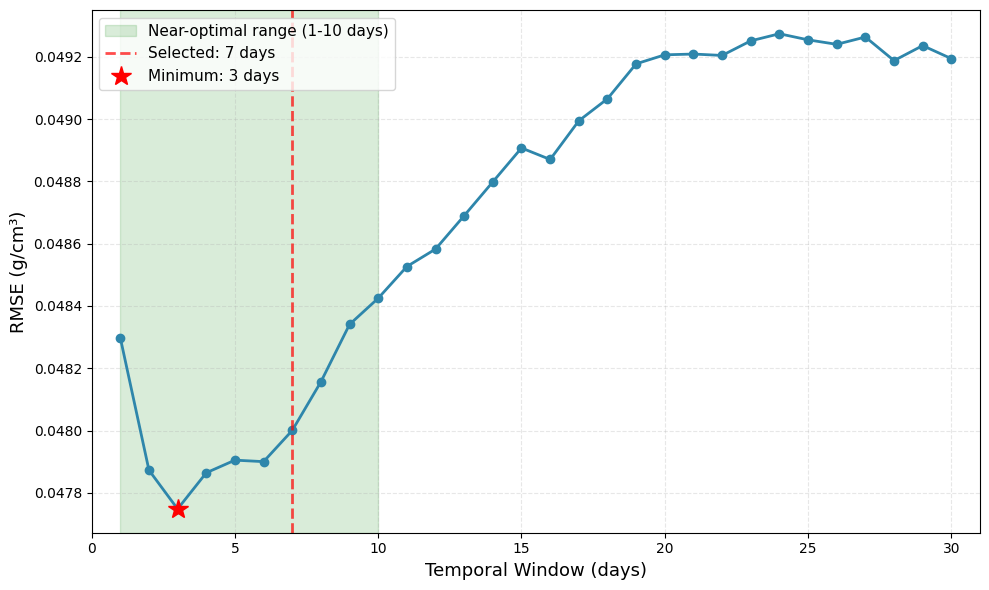

Performance at different temporal windows:
Lag   RMSE (4dp)   RMSE (2dp)  
-----------------------------------
1     0.0483       0.05        
2     0.0479       0.05        
3     0.0477       0.05        
4     0.0479       0.05        
5     0.0479       0.05        
6     0.0479       0.05        
7     0.0480       0.05        
8     0.0482       0.05        
9     0.0483       0.05        
10    0.0484       0.05        
11    0.0485       0.05        
12    0.0486       0.05        
13    0.0487       0.05        
14    0.0488       0.05        
15    0.0489       0.05        
16    0.0489       0.05        
17    0.0490       0.05        
18    0.0491       0.05        
19    0.0492       0.05        
20    0.0492       0.05        
21    0.0492       0.05        
22    0.0492       0.05        
23    0.0493       0.05        
24    0.0493       0.05        
25    0.0493       0.05        
26    0.0492       0.05        
27    0.0493       0.05        
28    0.0492       0.05  

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Your data
lags = {
    1: 0.048297745488371444,
    2: 0.04787259754002946,
    3: 0.04774812464026211,
    4: 0.047864282765987955,
    5: 0.04790486210413014,
    6: 0.047900083188100115,
    7: 0.04800027196648612,
    8: 0.048156373921787336,
    9: 0.048340695241799625,
    10: 0.04842486163302986,
    11: 0.04852654980931676,
    12: 0.048582674667974605,
    13: 0.04868987176840851,
    14: 0.04879853295458548,
    15: 0.04890732798261437,
    16: 0.04887035769664789,
    17: 0.048994558887090055,
    18: 0.04906530934531923,
    19: 0.04917752384584953,
    20: 0.04920641403582388,
    21: 0.04920894345382099,
    22: 0.049204440469635284,
    23: 0.04925130772727027,
    24: 0.049274068000215575,
    25: 0.049254502488469076,
    26: 0.04924014121967456,
    27: 0.04926364824614261,
    28: 0.04918785500081185,
    29: 0.049236040326916336,
    30: 0.04919416728020177
}

x = list(lags.keys())
y = list(lags.values())

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'o-', linewidth=2, markersize=6, color='#2E86AB')

# Formatting
ax.set_xlabel('Temporal Window (days)', fontsize=13)
ax.set_ylabel('RMSE (g/cm³)', fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--')

# Highlight the optimal range
ax.axvspan(1, 10, alpha=0.15, color='green', label='Near-optimal range (1-10 days)')
ax.axvline(x=7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Selected: 7 days')

# Mark the minimum
min_lag = min(lags.items(), key=lambda x: x[1])
ax.plot(min_lag[0], min_lag[1], 'r*', markersize=15, label=f'Minimum: {min_lag[0]} days')

ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(0, 31)

# Format y-axis with more precision
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.4f}'))

plt.tight_layout()
plt.show()

# Show the actual values rounded to different precisions
print("Performance at different temporal windows:")
print(f"{'Lag':<5} {'RMSE (4dp)':<12} {'RMSE (2dp)':<12}")
print("-" * 35)
for lag, rmse in lags.items():
    print(f"{lag:<5} {rmse:<12.4f} {rmse:<12.2f}")

In [ ]:
list(lags.values())

- XGBoost

In [18]:
with open('../experiments/results/tune_new/xgboost_climate_7d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

sampling_method = "gradient_based" if xgb_device == "cuda" else "uniform"
default_params_xgb = {
    "objective": "reg:squarederror",
    "seed": all_config.global_cfg.seed,
    "tree_method": "hist",
    "device": xgb_device,
    "verbosity": 0,
    "sampling_method": sampling_method
}


xgb_params_from_optuna=raw_config['performance']['hyperparameters']
xgb_params_from_optuna.update(default_params_xgb)

dtrain = xgb.DMatrix(X_train_7d, label=y_train)
dtest = xgb.DMatrix(X_test_7d)

xgb_7 = xgb.train(
    xgb_params_from_optuna,
    dtrain,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'], 
)

y_pred_xgb_7 = xgb_7.predict(dtest)

### Lag 14

In [21]:
climate14d_config = model_variant_selector(variant='climate_14d', data=raw_data)

processed_data_cat_14d=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=climate14d_config
)

## y_train and y_test doesn't change, so no need to re-process
X_train_14d = processed_data_cat_14d.x_train
X_test_14d = processed_data_cat_14d.x_val

- Extra Trees

In [22]:
with open('../experiments/results/tune_new/extratrees_climate_14d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

ext_hyp_from_optuna = raw_config['performance']['hyperparameters']


ext_trees_14=ExtraTreesRegressor(**ext_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

ext_trees_14.fit(X_train_14d, y_train)
y_pred_ext_14 = ext_trees_14.predict(X_test_14d)

- Random Forest

In [23]:
with open('../experiments/results/tune_new/rf_climate_14d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

rf_hyp_from_optuna = raw_config['performance']['hyperparameters']


rf_trees_14=RandomForestRegressor(**rf_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

rf_trees_14.fit(X_train_14d, y_train)
y_pred_rf_14 = rf_trees_14.predict(X_test_14d)

- LightGBM

In [24]:
with open('../experiments/results/tune_new/lightgbm_climate_14d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_14d, label=y_train)

lgbm_14 = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_14 = lgbm_14.predict(X_test_14d)

- XGBoost

In [25]:
with open('../experiments/results/tune_new/xgboost_climate_14d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

sampling_method = "gradient_based" if xgb_device == "cuda" else "uniform"
default_params_xgb = {
    "objective": "reg:squarederror",
    "seed": all_config.global_cfg.seed,
    "tree_method": "hist",
    "device": xgb_device,
    "verbosity": 0,
    "sampling_method": sampling_method
}


xgb_params_from_optuna=raw_config['performance']['hyperparameters']
xgb_params_from_optuna.update(default_params_xgb)

dtrain = xgb.DMatrix(X_train_14d, label=y_train)
dtest = xgb.DMatrix(X_test_14d)

xgb_14 = xgb.train(
    xgb_params_from_optuna,
    dtrain,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'], 
)

y_pred_xgb_14 = xgb_14.predict(dtest)

## Model Comparison

### Density

- Main configuration

In [22]:
main_model_results=pd.DataFrame({
    'EXT_Density': y_pred_ext_main,
    'RF_Density': y_pred_rf_main,
    'LGBM_Density': y_pred_lgbm_main,
    'XGB_Density': y_pred_xgb_main,
    'True_Density': y_test.values
})

main_model_results.head()

,EXT_Density,RF_Density,LGBM_Density,XGB_Density,True_Density
0,0.274272,0.247755,0.254605,0.258287,0.308333
1,0.270857,0.248233,0.256336,0.260336,0.264286
2,0.277096,0.248691,0.263672,0.267221,0.300000
3,0.279963,0.259595,0.267992,0.270378,0.300000
4,0.278483,0.266122,0.270703,0.271092,0.278571


In [26]:
main_model_results=pd.DataFrame({
    'EXT_Density': y_pred_ext_main,
    'RF_Density': y_pred_rf_main,
    'LGBM_Density': y_pred_lgbm_main,
    'XGB_Density': y_pred_xgb_main,
    'True_Density': y_test.values
})

main_model_results.head()

,EXT_Density,RF_Density,LGBM_Density,XGB_Density,True_Density
0,0.274272,0.247755,0.254605,0.258287,0.308333
1,0.270857,0.248233,0.256336,0.260336,0.264286
2,0.277096,0.248691,0.263672,0.267221,0.300000
3,0.279963,0.259595,0.267992,0.270378,0.300000
4,0.278483,0.266122,0.270703,0.271092,0.278571


In [27]:
climate_density_results=pd.DataFrame({
    'EXT_Density_climate_7': y_pred_ext_7,
    'RF_Density_climate_7': y_pred_rf_7,
    'LGBM_Density_climate_7': y_pred_lgbm_7,
    'XGB_Density_climate_7': y_pred_xgb_7,
    'True_Density': y_test.values
})

climate_density_results.head()

,EXT_Density_climate_7,RF_Density_climate_7,LGBM_Density_climate_7,XGB_Density_climate_7,True_Density
0,0.266471,0.247581,0.241216,0.240130,0.308333
1,0.266803,0.247643,0.239898,0.239190,0.264286
2,0.268122,0.247643,0.245383,0.244625,0.300000
3,0.269895,0.247643,0.252558,0.249720,0.300000
4,0.270819,0.247643,0.253235,0.250659,0.278571


In [28]:
climate_density_results_14=pd.DataFrame({
    'EXT_Density_climate_14': y_pred_ext_14,
    'RF_Density_climate_14': y_pred_rf_14,
    'LGBM_Density_climate_14': y_pred_lgbm_14,
    'XGB_Density_climate_14': y_pred_xgb_14,
    'True_Density': y_test.values
})

climate_density_results_14.head()

,EXT_Density_climate_14,RF_Density_climate_14,LGBM_Density_climate_14,XGB_Density_climate_14,True_Density
0,0.266636,0.231112,0.242894,0.233352,0.308333
1,0.265350,0.229886,0.247689,0.236630,0.264286
2,0.268282,0.233027,0.250566,0.241438,0.300000
3,0.270702,0.234756,0.252908,0.243956,0.300000
4,0.271303,0.235173,0.254869,0.245747,0.278571


* Climate 7 configuration

In [23]:
climate_density_results=pd.DataFrame({
    'EXT_Density_climate_7': y_pred_ext_7,
    'RF_Density_climate_7': y_pred_rf_7,
    'LGBM_Density_climate_7': y_pred_lgbm_7,
    'XGB_Density_climate_7': y_pred_xgb_7,
    'True_Density': y_test.values
})

climate_density_results.head()

,EXT_Density_climate_7,RF_Density_climate_7,LGBM_Density_climate_7,XGB_Density_climate_7,True_Density
0,0.266471,0.247584,0.239944,0.240130,0.308333
1,0.266803,0.247646,0.238482,0.239190,0.264286
2,0.268182,0.247646,0.242394,0.244625,0.300000
3,0.269955,0.247646,0.246544,0.249720,0.300000
4,0.270879,0.247646,0.249270,0.250659,0.278571


* Climate 14 configuration

In [24]:
climate_density_results_14=pd.DataFrame({
    'EXT_Density_climate_14': y_pred_ext_14,
    'RF_Density_climate_14': y_pred_rf_14,
    'LGBM_Density_climate_14': y_pred_lgbm_14,
    'XGB_Density_climate_14': y_pred_xgb_14,
    'True_Density': y_test.values
})

climate_density_results_14.head()

,EXT_Density_climate_14,RF_Density_climate_14,LGBM_Density_climate_14,XGB_Density_climate_14,True_Density
0,0.266636,0.232866,0.238363,0.233352,0.308333
1,0.265350,0.231462,0.245556,0.236630,0.264286
2,0.268282,0.234440,0.246495,0.241438,0.300000
3,0.270702,0.237269,0.248398,0.243956,0.300000
4,0.271303,0.236744,0.251258,0.245747,0.278571


### Metrics

- Density

In [29]:
print("==================\nMain Configuration\n==================")
display(compare_multiple_models(main_model_results, 'True_Density'))

print("=======================\nCLIMATE 7 Configuration\n=======================")
display(compare_multiple_models(climate_density_results, 'True_Density'))

print("========================\nCLIMATE 14 Configuration\n========================")
display(compare_multiple_models(climate_density_results_14, 'True_Density'))

Main Configuration


,EXT_Density,RF_Density,LGBM_Density,XGB_Density
RMSE,0.051531,0.052996,0.051216,0.051265
MBE,0.001152,0.002019,0.001910,0.002285
RSQ,0.680795,0.662381,0.684689,0.684076


CLIMATE 7 Configuration


,EXT_Density_climate_7,RF_Density_climate_7,LGBM_Density_climate_7,XGB_Density_climate_7
RMSE,0.048642,0.049503,0.048010,0.048148
MBE,0.001707,0.001687,0.002276,0.002721
RSQ,0.715579,0.705426,0.722929,0.721324


CLIMATE 14 Configuration


,EXT_Density_climate_14,RF_Density_climate_14,LGBM_Density_climate_14,XGB_Density_climate_14
RMSE,0.049210,0.050145,0.048835,0.048892
MBE,0.001605,0.001861,0.002329,0.002473
RSQ,0.708899,0.697738,0.713322,0.712649


In [25]:
print("==================\nMain Configuration\n==================")
display(compare_multiple_models(main_model_results, 'True_Density'))

print("=======================\nCLIMATE 7 Configuration\n=======================")
display(compare_multiple_models(climate_density_results, 'True_Density'))

print("========================\nCLIMATE 14 Configuration\n========================")
display(compare_multiple_models(climate_density_results_14, 'True_Density'))

Main Configuration


,EXT_Density,RF_Density,LGBM_Density,XGB_Density
RMSE,0.051531,0.052996,0.051216,0.051265
MBE,0.001152,0.002019,0.001910,0.002285
RSQ,0.680795,0.662381,0.684689,0.684076


CLIMATE 7 Configuration


,EXT_Density_climate_7,RF_Density_climate_7,LGBM_Density_climate_7,XGB_Density_climate_7
RMSE,0.048647,0.049515,0.048000,0.048148
MBE,0.001702,0.001681,0.002265,0.002721
RSQ,0.715522,0.705277,0.723036,0.721324


CLIMATE 14 Configuration


,EXT_Density_climate_14,RF_Density_climate_14,LGBM_Density_climate_14,XGB_Density_climate_14
RMSE,0.049211,0.050304,0.048933,0.048892
MBE,0.001603,0.001663,0.002382,0.002473
RSQ,0.708884,0.695812,0.712164,0.712649


- SWE

In [26]:
main_model_swe_results=pd.DataFrame({
    'EXT_SWE': main_model_results.EXT_Density.values*X_test_main.Snow_Depth.values,
    'RF_SWE': main_model_results.RF_Density.values*X_test_main.Snow_Depth.values,
    'LGBM_SWE': main_model_results.LGBM_Density.values*X_test_main.Snow_Depth.values,
    'XGB_SWE': main_model_results.XGB_Density.values*X_test_main.Snow_Depth.values,
    'True_SWE': raw_data.x_val.SWE.values,
})

main_model_swe_results.head()

,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE,True_SWE
0,8.359807,7.551563,7.760360,7.872575,9.398
1,9.631689,8.827179,9.115292,9.257566,9.398
2,9.149716,8.211768,8.706452,8.823651,9.906
3,9.244391,8.571824,8.849098,8.927877,9.906
4,9.902841,9.463315,9.626202,9.640039,9.906


In [ ]:
climate_swe_results=pd.DataFrame({
    'True_SWE': raw_data.x_val.SWE.values,
    'EXT_SWE_climate_7': climate_density_results.EXT_Density_climate_7.values*X_test_7d.Snow_Depth.values,
    'RF_SWE_climate_7': climate_density_results.RF_Density_climate_7.values*X_test_7d.Snow_Depth.values,
    'LGBM_SWE_climate_7': climate_density_results.LGBM_Density_climate_7.values*X_test_7d.Snow_Depth.values,
    'XGB_SWE_climate_7': climate_density_results.XGB_Density_climate_7.values*X_test_7d.Snow_Depth.values,
})

climate_swe_results.head()

,True_SWE,EXT_SWE_climate,RF_SWE_climate,LGBM_SWE_climate,XGB_SWE_climate
0,9.398,8.122034,7.546353,7.313485,7.319155
1,9.398,9.487531,8.806277,8.480415,8.505586
2,9.906,8.855378,8.177257,8.003835,8.077516
3,9.906,8.913913,8.177257,8.140875,8.245748
4,9.906,9.632469,8.806277,8.864030,8.913432


In [29]:
climate_swe_results_14=pd.DataFrame({
    'True_SWE': raw_data.x_val.SWE.values,
    'EXT_SWE_climate_14': climate_density_results_14.EXT_Density_climate_14.values*X_test_14d.Snow_Depth.values,
    'RF_SWE_climate_14': climate_density_results_14.RF_Density_climate_14.values*X_test_14d.Snow_Depth.values,
    'LGBM_SWE_climate_14': climate_density_results_14.LGBM_Density_climate_14.values*X_test_14d.Snow_Depth.values,
    'XGB_SWE_climate_14': climate_density_results_14.XGB_Density_climate_14.values*X_test_14d.Snow_Depth.values,
})

climate_swe_results_14.head()

,True_SWE,EXT_SWE_climate_14,RF_SWE_climate_14,LGBM_SWE_climate_14,XGB_SWE_climate_14
0,9.398,8.127074,7.097754,7.265300,7.112563
1,9.398,9.435841,8.230805,8.731959,8.414569
2,9.906,8.858683,7.741197,8.139251,7.972278
3,9.906,8.938589,7.834631,8.202096,8.055414
4,9.906,9.647550,8.418611,8.934732,8.738749


In [31]:
print("==================\nMain Configuration\n==================")
display(compare_multiple_models(main_model_swe_results, 'True_SWE'))

print("=======================\nCLIMATE 7 Configuration\n=======================")
display(compare_multiple_models(climate_swe_results, 'True_SWE'))

print("========================\nCLIMATE 14 Configuration\n========================")
display(compare_multiple_models(climate_swe_results_14, 'True_SWE'))

Main Configuration


,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE
RMSE,5.493810,5.752251,5.393536,5.349604
MBE,0.075129,0.117492,0.171727,0.188284
RSQ,0.964327,0.960892,0.965618,0.966175


CLIMATE 7 Configuration


,EXT_SWE_climate,RF_SWE_climate,LGBM_SWE_climate,XGB_SWE_climate
RMSE,5.063582,5.453277,5.028539,5.012549
MBE,0.123620,0.128247,0.212589,0.259325
RSQ,0.969696,0.964852,0.970114,0.970303


CLIMATE 14 Configuration


,EXT_SWE_climate_14,RF_SWE_climate_14,LGBM_SWE_climate_14,XGB_SWE_climate_14
RMSE,5.122170,5.490455,5.157787,5.076322
MBE,0.132576,0.143577,0.234600,0.236290
RSQ,0.968990,0.964371,0.968558,0.969543


Comparing Lags 7 and 14, Lag 7 is a little bit better over all. We will now store the results of Lag 7 for further analysis. Also, we will store the LightGBM model for further use because it slightly outperforms other models for density estimation.

## Store Predictions for Later Use

In [33]:
## main config
main_model_results.drop('True_Density', axis=1).to_parquet('../results/density/ML_models_predictions_baseline.parquet', index=False, compression='gzip')
main_model_swe_results.drop('True_SWE', axis=1).to_parquet('../results/swe/ML_models_predictions_baseline.parquet', index=False, compression='gzip')

## climate 7 config
climate_density_results.drop('True_Density', axis=1).to_parquet('../results/density/ML_models_predictions_climate.parquet', index=True, compression='gzip')
climate_swe_results.drop('True_SWE', axis=1).to_parquet('../results/swe/ML_models_predictions_climate.parquet', index=True, compression='gzip')

## Store the Best Models (LightGBM)

In [30]:
lgbm_main.save_model(filename="../ML_weights/main_density_model.txt")
lgbm_7.save_model(filename="../ML_weights/climate7_density_model.txt")

## Direct SWE Estimation

Only the LGBM model results are presented here because it's the best model. You can find the optimization results for LightGBM and XGBoost in `../experiments/optuna_studies_SWE.db`.

- Main Configuration

In [62]:
import os
import glob
import yaml
from pathlib import Path

# Directory containing the YAML files
yaml_dir = '../experiments/results/tune_SWE_target2/'

# Get all YAML files
yaml_files = glob.glob(os.path.join(yaml_dir, '*.yaml'))

# Load data once (outside loop)
raw_data = load_data('../data/data_splits_SWE.pkl', final_eval=True)
all_config = load_config(config_path='../experiments/hyperparameters.yaml')

# Storage for results
results = []

# Loop through each YAML file
for yaml_file in yaml_files:
    # Load YAML
    with open(yaml_file, mode='r', encoding="utf-8") as file:
        raw_config = yaml.safe_load(file)
    
    # Extract model info from config
    model_name = raw_config['model']['name']
    variant = raw_config['model']['variant']
    encoder = raw_config['model']['encoder']
    
    print(f"\n{'='*50}")
    print(f"Processing: {model_name} - {variant}")
    print(f"{'='*50}")
    
    # Get variant config
    variant_config = model_variant_selector(variant=variant, data=raw_data)
    
    # Process data
    processed_data = ecnoder_preprocessor(
        encoder=encoder,
        cfg=all_config.global_cfg,
        data=variant_config
    )
    
    X_train = processed_data.x_train
    X_test = processed_data.x_val
    y_train = processed_data.y_train
    y_test = processed_data.y_val
    
    # Get hyperparameters from YAML
    params_from_optuna = raw_config['performance']['hyperparameters'].copy()
    
    # Train and predict based on model type
    if model_name == 'lightgbm':
        default_params = {
            'objective': 'regression',
            'metric': 'rmse',
            'random_state': all_config.global_cfg.seed,
            "force_col_wise": True,
            "verbosity": all_config.global_cfg.verbosity,
            "deterministic": True
        }
        params_from_optuna.update(default_params)
        
        train_data = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(
            params_from_optuna,
            train_data,
            num_boost_round=raw_config['performance']['metrics']['best_iteration']
        )
        y_pred = model.predict(X_test)
        
    elif model_name == 'xgboost':
        # Add XGBoost training code here
        import xgboost as xgb
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test)
        model = xgb.train(
            params_from_optuna,
            dtrain,
            num_boost_round=raw_config['performance']['metrics']['best_iteration']
        )
        y_pred = model.predict(dtest)
        
    elif model_name in ['rf', 'extratrees']:
        # Add sklearn models
        from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
        
        if model_name == 'rf':
            model = RandomForestRegressor(**params_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=-1)
        else:
            model = ExtraTreesRegressor(**params_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
    r2 = r2_score(y_true=y_test, y_pred=y_pred)
    
    # Store results
    results.append({
        'model': model_name,
        'variant': variant,
        'rmse': rmse,
        'r2': r2,
        'yaml_file': Path(yaml_file).name
    })
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

# Convert to DataFrame for easy viewing
import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("SUMMARY OF ALL MODELS")
print("="*50)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../experiments/results/direct_swe_test_results.csv', index=False)


Processing: rf - climate_7d


KeyboardInterrupt: 

In [3]:
import os
import glob
import yaml
from pathlib import Path

# Directory containing the YAML files
yaml_dir = '../experiments/results/tune_SWE_target/'

# Get all YAML files
yaml_files = glob.glob(os.path.join(yaml_dir, '*.yaml'))

# Load data once (outside loop)
raw_data = load_data('../data/data_splits_SWE.pkl', final_eval=True)
all_config = load_config(config_path='../experiments/hyperparameters.yaml')

# Storage for results
results = []

# Loop through each YAML file
for yaml_file in yaml_files:
    # Load YAML
    with open(yaml_file, mode='r', encoding="utf-8") as file:
        raw_config = yaml.safe_load(file)
    
    # Extract model info from config
    model_name = raw_config['model']['name']
    variant = raw_config['model']['variant']
    encoder = raw_config['model']['encoder']
    
    print(f"\n{'='*50}")
    print(f"Processing: {model_name} - {variant}")
    print(f"{'='*50}")
    
    # Get variant config
    variant_config = model_variant_selector(variant=variant, data=raw_data)
    
    # Process data
    processed_data = ecnoder_preprocessor(
        encoder=encoder,
        cfg=all_config.global_cfg,
        data=variant_config
    )
    
    X_train = processed_data.x_train
    X_test = processed_data.x_val
    y_train = processed_data.y_train
    y_test = processed_data.y_val
    
    # Get hyperparameters from YAML
    params_from_optuna = raw_config['performance']['hyperparameters'].copy()
    
    # Train and predict based on model type
    if model_name == 'lightgbm':
        default_params = {
            'objective': 'regression',
            'metric': 'rmse',
            'random_state': all_config.global_cfg.seed,
            "force_col_wise": True,
            "verbosity": all_config.global_cfg.verbosity,
            "deterministic": True
        }
        params_from_optuna.update(default_params)
        
        train_data = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(
            params_from_optuna,
            train_data,
            num_boost_round=raw_config['performance']['metrics']['best_iteration']
        )
        y_pred = model.predict(X_test)
        
    elif model_name == 'xgboost':
        # Add XGBoost training code here
        import xgboost as xgb
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dtest = xgb.DMatrix(X_test)
        model = xgb.train(
            params_from_optuna,
            dtrain,
            num_boost_round=raw_config['performance']['metrics']['best_iteration']
        )
        y_pred = model.predict(dtest)
        
    elif model_name in ['rf', 'extratrees']:
        # Add sklearn models
        from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
        
        if model_name == 'rf':
            model = RandomForestRegressor(**params_from_optuna, random_state=all_config.global_cfg.seed)
        else:
            model = ExtraTreesRegressor(**params_from_optuna, random_state=all_config.global_cfg.seed)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    rmse = root_mean_squared_error(y_true=y_test, y_pred=y_pred)
    r2 = r2_score(y_true=y_test, y_pred=y_pred)
    
    # Store results
    results.append({
        'model': model_name,
        'variant': variant,
        'rmse': rmse,
        'r2': r2,
        'yaml_file': Path(yaml_file).name
    })
    
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

# Convert to DataFrame for easy viewing
import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("SUMMARY OF ALL MODELS")
print("="*50)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../experiments/results/direct_swe_test_results.csv', index=False)


Processing: xgboost - main
RMSE: 5.8512
R²: 0.9595

Processing: lightgbm - main
RMSE: 5.6882
R²: 0.9618

Processing: extratrees - climate_14d
RMSE: 5.2863
R²: 0.9670

Processing: rf - climate_14d
RMSE: 5.3995
R²: 0.9655

Processing: extratrees - climate_7d
RMSE: 5.2382
R²: 0.9676

Processing: xgboost - climate_7d
RMSE: 5.4240
R²: 0.9652

Processing: lightgbm - climate_14d
RMSE: 5.3760
R²: 0.9658

Processing: lightgbm - climate_7d
RMSE: 5.2507
R²: 0.9674

Processing: extratrees - main
RMSE: 5.5959
R²: 0.9630

Processing: rf - climate_7d
RMSE: 5.3338
R²: 0.9664

Processing: xgboost - climate_14d
RMSE: 5.5004
R²: 0.9642

Processing: rf - main
RMSE: 5.8790
R²: 0.9591

SUMMARY OF ALL MODELS
     model     variant     rmse       r2                                               yaml_file
   xgboost        main 5.851216 0.959535           xgboost_main_tune_target_20251211_150214.yaml
  lightgbm        main 5.688151 0.961759          lightgbm_main_tune_target_20251211_150214.yaml
extratrees cl

In [60]:
raw_data=load_data('../data/data_splits_SWE.pkl', final_eval=True) # raw_data
main_config = model_variant_selector(variant='main', data=raw_data) # main configuration
all_config = load_config(config_path='../experiments/hyperparameters.yaml') # all configuration

processed_data_cat_main=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=main_config
)

X_train_main = processed_data_cat_main.x_train
X_test_main = processed_data_cat_main.x_val
y_train = processed_data_cat_main.y_train
y_test = processed_data_cat_main.y_val


with open('../experiments/results/tune_SWE/lightgbm_main_tune_target_20250908_135834.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_main, label=y_train)

lgbm_main = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_main = lgbm_main.predict(X_test_main)
main_density_swe = float(compare_multiple_models(main_model_swe_results, 'True_SWE').loc['RMSE', 'LGBM_SWE'])
percentage_better = (root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_main) - main_density_swe)/root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_main)
print("==================\nMain Configuration\n==================")
print(f"RMSE: {root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_main):.4f}")
print(f"RMSE: {r2_score(y_true=y_test, y_pred=y_pred_lgbm_main):.4f}")
print(f"Density-based SWE has ~ {percentage_better*100:.0f}% lower RMSE")

Main Configuration
RMSE: 5.6686
RMSE: 0.9620
Density-based SWE has ~ 5% lower RMSE


In [3]:
((5.267 - 5.029)/5.267)*100

4.518701348015957

In [64]:
clim7_config = model_variant_selector(variant='climate_7d', data=raw_data)
all_config = load_config(config_path='../experiments/hyperparameters.yaml')

processed_data_cat_main=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=clim7_config
)


X_train_clim7 = processed_data_cat_main.x_train
X_test_clim7 = processed_data_cat_main.x_val

with open('../experiments/results/tune_SWE/lightgbm_climate_7d_tune_target_20250908_135834.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_clim7, label=y_train)

lgbm_clim7 = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_clim7 = lgbm_clim7.predict(X_test_clim7)
main_density_swe = float(compare_multiple_models(climate_swe_results, 'True_SWE').loc['RMSE', 'LGBM_SWE_climate'])
percentage_better = (root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_clim7) - main_density_swe)/root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_clim7)
print("=======================\nCLIMATE 7 Configuration\n=======================")
print(f"RMSE: {root_mean_squared_error(y_true=y_test, y_pred=y_pred_lgbm_clim7):.4f}")
print(f"RMSE: {r2_score(y_true=y_test, y_pred=y_pred_lgbm_clim7):.4f}")
print(f"Density-based SWE has ~ {percentage_better*100:.0f}% lower RMSE")

CLIMATE 7 Configuration
RMSE: 5.2668
RMSE: 0.9672
Density-based SWE has ~ 5% lower RMSE


On a final note, most of this code will be automated in a production environment. However, the goal here is to help the reader understand our implementation as much as possible. Therefore, we have decided to make modeling using the optimal hyperparameters explicit. Readers should refer to `../snowmodels` for the implementation of all local functions and classes.

# The End!

In [3]:
raw_data=load_data('../data/data_splits.pkl', final_eval=True)
main_config = model_variant_selector(variant='main', data=raw_data)
all_config = load_config(config_path='../experiments/hyperparameters.yaml')

processed_data_cat_main=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=main_config
)


X_train_main = processed_data_cat_main.x_train
X_test_main = processed_data_cat_main.x_val
y_train = processed_data_cat_main.y_train
y_test = processed_data_cat_main.y_val

### Extra Trees

In [4]:
with open('../experiments/results/tune_new/extratrees_main_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

ext_hyp_from_optuna = raw_config['performance']['hyperparameters']


ext_trees_main=ExtraTreesRegressor(**ext_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

ext_trees_main.fit(X_train_main, y_train)
y_pred_ext_main = ext_trees_main.predict(X_test_main)

In [84]:
X_train_main.columns

Index(['Elevation', 'Snow_Depth', 'DOWY', 'Latitude', 'Longitude',
       'Snow_Class'],
      dtype='object')

### Random Forest

In [5]:
with open('../experiments/results/tune_new/rf_main_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

rf_hyp_from_optuna = raw_config['performance']['hyperparameters']


rf_trees_main=RandomForestRegressor(**rf_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

rf_trees_main.fit(X_train_main, y_train)
y_pred_rf_main = rf_trees_main.predict(X_test_main)

### LightGBM

In [66]:
with open('../experiments/results/tune_new/lightgbm_main_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_main, label=y_train)

lgbm_main = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_main = lgbm_main.predict(X_test_main)

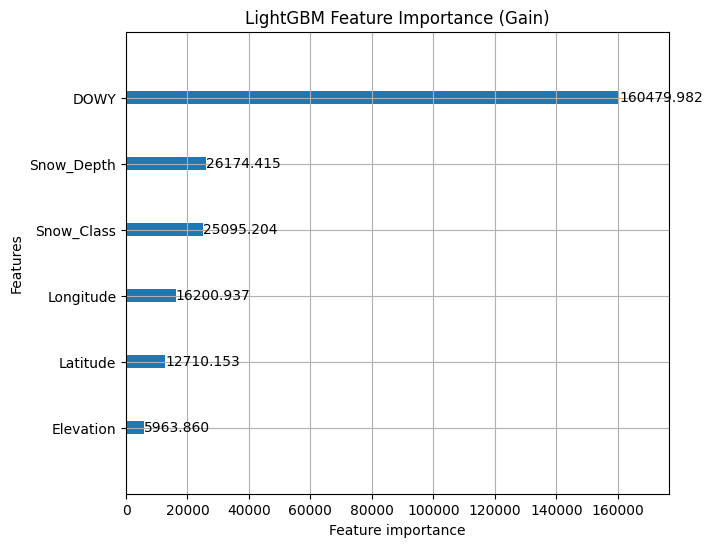

In [70]:
from matplotlib import pyplot as plt
# Plot feature importance using Split
lgb.plot_importance(lgbm_main, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

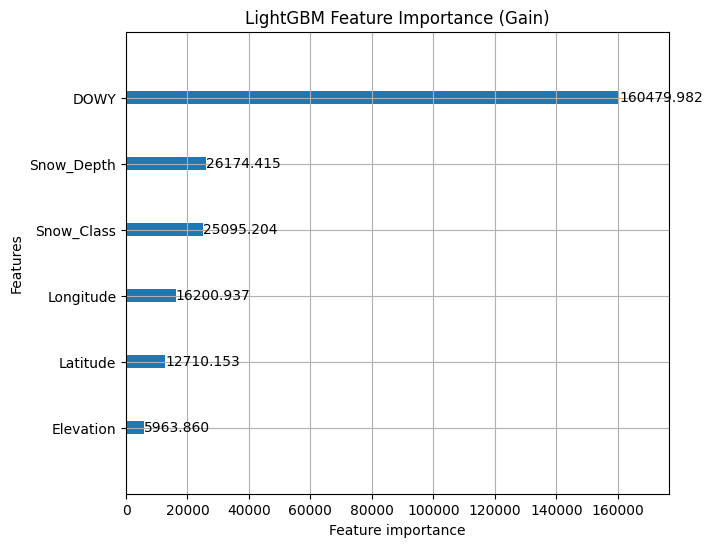

In [40]:
from matplotlib import pyplot as plt
# Plot feature importance using Split
lgb.plot_importance(lgbm_main, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

In [47]:
import shap


explainer = shap.TreeExplainer(lgbm_main)
shap_values = explainer(X_test_main)

In [48]:
shap_df=pd.DataFrame(abs(shap_values.values), columns=lgbm_main.feature_name())
shap_df
shap_df=shap_df.assign(Raw_snow_class = raw_data.x_val.Snow_Class.values)

shap_df=shap_df.rename(columns={
        'Snow_Class': 'Snow Class',
        'Snow_Depth': 'Snow Depth',
    })

shap_df

,Elevation,Snow Depth,DOWY,Latitude,Longitude,Snow Class,Raw_snow_class
0,0.003626,0.000806,0.067875,0.001858,0.024820,0.006085,Prairie
1,0.003152,0.003325,0.065676,0.000443,0.024687,0.005729,Prairie
2,0.003751,0.001988,0.061057,0.000658,0.026601,0.005760,Prairie
3,0.003799,0.001797,0.058191,0.000507,0.027471,0.005566,Prairie
4,0.003438,0.002758,0.056389,0.001103,0.027722,0.005196,Prairie
...,...,...,...,...,...,...,...
534813,0.001756,0.006958,0.068474,0.002618,0.004834,0.007343,Prairie
534814,0.001756,0.006961,0.068460,0.002627,0.004843,0.007343,Prairie
534815,0.001789,0.006861,0.067963,0.002531,0.005179,0.007404,Prairie
534816,0.001789,0.006864,0.067913,0.002535,0.005179,0.007453,Prairie


In [49]:
shap_df.drop('Raw_snow_class', axis=1).mean().sort_values(ascending=False)

DOWY          0.052164
Snow Class    0.011241
Snow Depth    0.011115
Longitude     0.010083
Latitude      0.006069
Elevation     0.003332
dtype: float64

In [50]:
import seaborn as sns

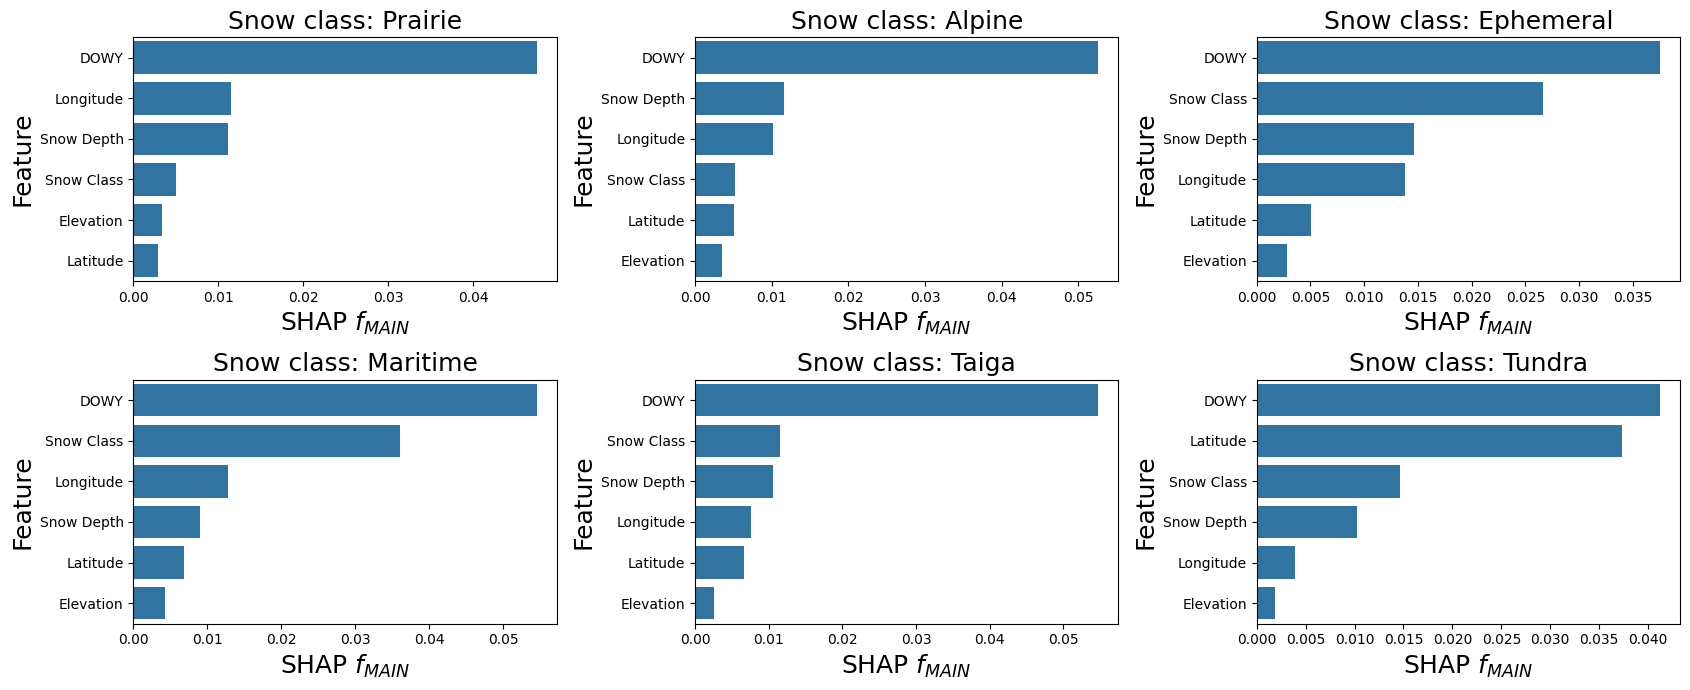

In [51]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(17, 7))
ax = ax.flatten()  # flatten the 2D array of axes into 1D

for i, sc in enumerate(shap_df.Raw_snow_class.unique()):
    current_class = (
        shap_df.query("Raw_snow_class == @sc")
        .drop('Raw_snow_class', axis=1)
        .mean()
        .sort_values(ascending=False)
        .to_frame()
        .reset_index()
        .rename(columns={'index': 'Feature', 0: 'Importance'})
    )
    
    sns.barplot(x="Importance", y="Feature", data=current_class, ax=ax[i])
    ax[i].set_title(f"Snow class: {sc}", fontsize=18)
    ax[i].set_xlabel("SHAP $f_{MAIN}$", fontsize=18)
    ax[i].set_ylabel("Feature", fontsize=18)
    ax[i].tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('../plots/shap_by_class.jpg', dpi=300, bbox_inches='tight')
plt.show()


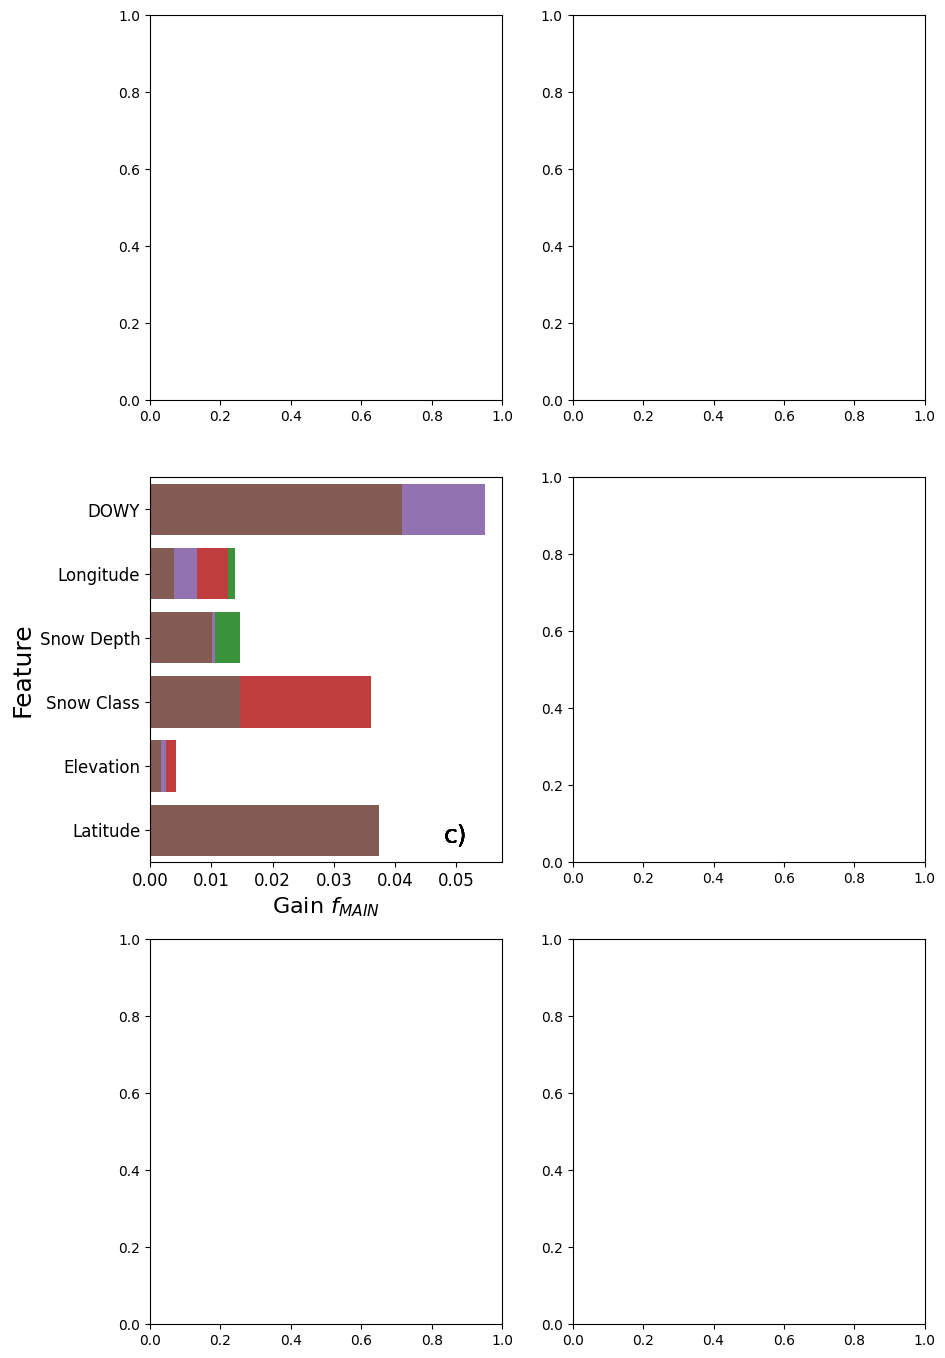

In [52]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 17))

for sc in shap_df.Raw_snow_class.unique():

    current_class = shap_df.query("Raw_snow_class == @sc").drop('Raw_snow_class', axis = 1).mean().sort_values(ascending=False)

    current_class= current_class.to_frame().reset_index().rename(columns={
        'index': 'Feature',
        0 : 'Importance'
    })
    
    
    sns.barplot(x="Importance", y="Feature", data=current_class, ax=ax[1, 0])
    ax[1, 0].set_xlabel("Gain $f_{MAIN}$", fontsize=16)
    ax[1, 0].set_ylabel("Feature", fontsize=18)
    ax[1, 0].tick_params(labelsize=12)
    ax[1, 0].text(0.90, 0.10, 'c)', transform=ax[1, 0].transAxes, fontsize=18, va='top', ha='right')
    # display(current_class)

In [53]:
for sc in shap_df.Raw_snow_class.unique():

    current_class = shap_df.query("Raw_snow_class == @sc").drop('Raw_snow_class', axis = 1)
    print(f'~~~~~Snow class: {sc}~~~~~~~')
    display(current_class.mean().sort_values(ascending=False))

~~~~~Snow class: Prairie~~~~~~~


DOWY          0.047447
Longitude     0.011445
Snow Depth    0.011112
Snow Class    0.005056
Elevation     0.003387
Latitude      0.002916
dtype: float64

~~~~~Snow class: Alpine~~~~~~~


DOWY          0.052580
Snow Depth    0.011603
Longitude     0.010219
Snow Class    0.005207
Latitude      0.005080
Elevation     0.003451
dtype: float64

~~~~~Snow class: Ephemeral~~~~~~~


...

DOWY          0.054479
Snow Class    0.036051
Longitude     0.012789
Snow Depth    0.009000
Latitude      0.006893
Elevation     0.004332
dtype: float64

~~~~~Snow class: Taiga~~~~~~~


DOWY          0.054727
Snow Class    0.011538
Snow Depth    0.010618
Longitude     0.007640
Latitude      0.006665
Elevation     0.002637
dtype: float64

~~~~~Snow class: Tundra~~~~~~~


DOWY          0.041203
Latitude      0.037300
Snow Class    0.014623
Snow Depth    0.010204
Longitude     0.003872
Elevation     0.001870
dtype: float64

In [26]:
shap_df.columns

Index(['Elevation', 'Snow_Depth', 'DOWY', 'Latitude', 'Longitude',
       'Snow_Class', 'Raw_snow_class'],
      dtype='object')

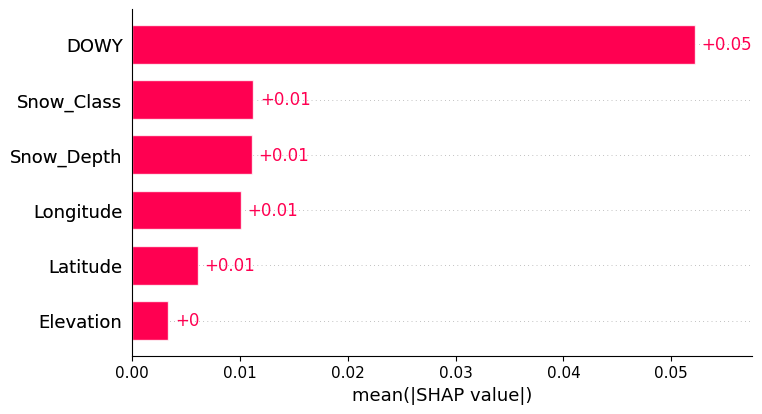

In [10]:
shap.plots.bar(shap_values)

In [16]:
# shap.plots.bar(shap_values.abs.max(0))

### XGBoost

In [11]:
with open('../experiments/results/tune_new/xgboost_main_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

sampling_method = "gradient_based" if xgb_device == "cuda" else "uniform"
default_params_xgb = {
    "objective": "reg:squarederror",
    "seed": all_config.global_cfg.seed,
    "tree_method": "hist",
    "device": xgb_device,
    "verbosity": 0,
    "sampling_method": sampling_method
}


xgb_params_from_optuna=raw_config['performance']['hyperparameters']
xgb_params_from_optuna.update(default_params_xgb)

dtrain = xgb.DMatrix(X_train_main, label=y_train)
dtest = xgb.DMatrix(X_test_main)

xgb_main = xgb.train(
    xgb_params_from_optuna,
    dtrain,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'], 
)

y_pred_xgb_main = xgb_main.predict(dtest)

In [ ]:
pd.DataFrame(
        data={
            "Feature": xgb_main.feature_names,
            "Importance": xgb_main.get_score(importance_type='gain').values()
        }
).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,DOWY,93.200340
5,Snow_Class,42.732197
1,Snow_Depth,8.157521
4,Longitude,4.461824
3,Latitude,3.258300
0,Elevation,2.267700


In [37]:
pd.DataFrame(
        data={
            "Feature": xgb_main.feature_names,
            "Importance": xgb_main.get_score(importance_type='total_gain').values()
        }
    ).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,DOWY,176521.437500
1,Snow_Depth,28657.371094
5,Snow_Class,27861.392578
4,Longitude,17753.599609
3,Latitude,11765.719727
0,Elevation,5680.587891


## Model Comparison

* Density

In [12]:
main_model_results=pd.DataFrame({
    'EXT_Density': y_pred_ext_main,
    'RF_Density': y_pred_rf_main,
    'LGBM_Density': y_pred_lgbm_main,
    'XGB_Density': y_pred_xgb_main,
    'True_Density': y_test.values
})

main_model_results.head()

,EXT_Density,RF_Density,LGBM_Density,XGB_Density,True_Density
0,0.274272,0.247755,0.254605,0.259430,0.308333
1,0.270857,0.248233,0.256336,0.259339,0.264286
2,0.277096,0.248691,0.263672,0.266172,0.300000
3,0.279963,0.259595,0.267992,0.270270,0.300000
4,0.278483,0.266122,0.270703,0.269889,0.278571


In [11]:
main_model_results=pd.DataFrame({
    'EXT_Density': y_pred_ext_main,
    'RF_Density': y_pred_rf_main,
    'LGBM_Density': y_pred_lgbm_main,
    'XGB_Density': y_pred_xgb_main,
    'True_Density': y_test.values
})

main_model_results.head()

,EXT_Density,RF_Density,LGBM_Density,XGB_Density,True_Density
0,0.274272,0.247755,0.254605,0.258287,0.308333
1,0.270857,0.248233,0.256336,0.260336,0.264286
2,0.277096,0.248691,0.263672,0.267221,0.300000
3,0.279963,0.259595,0.267992,0.270378,0.300000
4,0.278483,0.266122,0.270703,0.271092,0.278571


In [13]:
compare_multiple_models(main_model_results, 'True_Density')

,EXT_Density,RF_Density,LGBM_Density,XGB_Density
RMSE,0.051531,0.052996,0.051216,0.051304
MBE,0.001152,0.002019,0.001910,0.002050
RSQ,0.680795,0.662381,0.684689,0.683600


In [12]:
compare_multiple_models(main_model_results, 'True_Density')

,EXT_Density,RF_Density,LGBM_Density,XGB_Density
RMSE,0.051531,0.052996,0.051216,0.051265
MBE,0.001152,0.002019,0.001910,0.002285
RSQ,0.680795,0.662381,0.684689,0.684076


* SWE

In [13]:
main_model_swe_results=pd.DataFrame({
    'EXT_SWE': main_model_results.EXT_Density.values*X_test_main.Snow_Depth.values,
    'RF_SWE': main_model_results.RF_Density.values*X_test_main.Snow_Depth.values,
    'LGBM_SWE': main_model_results.LGBM_Density.values*X_test_main.Snow_Depth.values,
    'XGB_SWE': main_model_results.XGB_Density.values*X_test_main.Snow_Depth.values,
    'True_SWE': raw_data.x_val.SWE.values,
})

main_model_swe_results.head()

,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE,True_SWE
0,8.359807,7.551563,7.760360,7.872575,9.398
1,9.631689,8.827179,9.115292,9.257566,9.398
2,9.149716,8.211768,8.706452,8.823651,9.906
3,9.244391,8.571824,8.849098,8.927877,9.906
4,9.902841,9.463315,9.626202,9.640039,9.906


In [14]:
main_model_swe_results=pd.DataFrame({
    'EXT_SWE': main_model_results.EXT_Density.values*X_test_main.Snow_Depth.values,
    'RF_SWE': main_model_results.RF_Density.values*X_test_main.Snow_Depth.values,
    'LGBM_SWE': main_model_results.LGBM_Density.values*X_test_main.Snow_Depth.values,
    'XGB_SWE': main_model_results.XGB_Density.values*X_test_main.Snow_Depth.values,
    'True_SWE': raw_data.x_val.SWE.values,
})

main_model_swe_results.head()

,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE,True_SWE
0,8.359807,7.551563,7.760360,7.907417,9.398
1,9.631689,8.827179,9.115292,9.222110,9.398
2,9.149716,8.211768,8.706452,8.788989,9.906
3,9.244391,8.571824,8.849098,8.924303,9.906
4,9.902841,9.463315,9.626202,9.597241,9.906


In [15]:
compare_multiple_models(main_model_swe_results, 'True_SWE')

,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE
RMSE,5.493810,5.752251,5.393536,5.387922
MBE,0.075129,0.117492,0.171727,0.177806
RSQ,0.964327,0.960892,0.965618,0.965689


In [14]:
compare_multiple_models(main_model_swe_results, 'True_SWE')

,EXT_SWE,RF_SWE,LGBM_SWE,XGB_SWE
RMSE,5.493810,5.752251,5.393536,5.349604
MBE,0.075129,0.117492,0.171727,0.188284
RSQ,0.964327,0.960892,0.965618,0.966175


* LightGBM for the Win - it did slightly better in density estimation.

## Adding Climatology

### Extra Trees

In [53]:
climate7d_config = model_variant_selector(variant='climate_7d', data=raw_data)

processed_data_cat_7d=ecnoder_preprocessor(
    encoder='target',
    cfg=all_config.global_cfg,
    data=climate7d_config
)


X_train_7d = processed_data_cat_7d.x_train
X_test_7d = processed_data_cat_7d.x_val

In [20]:
with open('../experiments/results/tune_new/extratrees_climate_7d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

ext_hyp_from_optuna = raw_config['performance']['hyperparameters']


ext_trees_7=ExtraTreesRegressor(**ext_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

ext_trees_7.fit(X_train_7d, y_train)
y_pred_ext_7 = ext_trees_7.predict(X_test_7d)

In [79]:
ext_trees

NameError: name 'ext_trees' is not defined

### Random Forest

In [21]:
with open('../experiments/results/tune_new/rf_climate_7d_tune_target_20250902_232842.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

rf_hyp_from_optuna = raw_config['performance']['hyperparameters']


rf_trees_7=RandomForestRegressor(**rf_hyp_from_optuna, random_state=all_config.global_cfg.seed, n_jobs=all_config.global_cfg.n_jobs)

rf_trees_7.fit(X_train_7d, y_train)
y_pred_rf_7 = rf_trees_7.predict(X_test_7d)

### LightGBM

In [72]:
with open('../experiments/results/tune_new/lightgbm_climate_7d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

default_params= {
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': all_config.global_cfg.seed,
    "force_col_wise": True,
    "verbosity": all_config.global_cfg.verbosity,
    "deterministic": True
}

params_from_optuna = raw_config['performance']['hyperparameters']
params_from_optuna.update(default_params)

train_data = lgb.Dataset(X_train_7d, label=y_train)

lgbm_7 = lgb.train(
    params_from_optuna,
    train_data,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'] # best iteration from Optuna
)

y_pred_lgbm_7 = lgbm_7.predict(X_test_7d)

In [72]:
raw_config['performance']['metrics']['best_iteration'], params_from_optuna

(99,
 {'num_leaves': 202,
  'learning_rate': 0.04239942996444115,
  'min_child_samples': 86,
  'reg_alpha': 1.0290351857869753e-05,
  'reg_lambda': 0.005880313324688824,
  'max_depth': 9,
  'objective': 'regression',
  'metric': 'rmse',
  'random_state': 10,
  'force_col_wise': True,
  'verbosity': -1,
  'deterministic': True})

### XGBoost

In [23]:
with open('../experiments/results/tune_new/xgboost_climate_7d_tune_target_20250902_200431.yaml', mode='r', encoding="utf-8") as file:
            raw_config = yaml.safe_load(file)

sampling_method = "gradient_based" if xgb_device == "cuda" else "uniform"
default_params_xgb = {
    "objective": "reg:squarederror",
    "seed": all_config.global_cfg.seed,
    "tree_method": "hist",
    "device": xgb_device,
    "verbosity": 0,
    "sampling_method": sampling_method
}


xgb_params_from_optuna=raw_config['performance']['hyperparameters']
xgb_params_from_optuna.update(default_params_xgb)

dtrain = xgb.DMatrix(X_train_7d, label=y_train)
dtest = xgb.DMatrix(X_test_7d)

xgb_7 = xgb.train(
    xgb_params_from_optuna,
    dtrain,
    num_boost_round=raw_config['performance']['metrics']['best_iteration'], 
)

y_pred_xgb_7 = xgb_7.predict(dtest)

In [24]:
pd.DataFrame(
        data={
            "Feature": xgb_7.feature_names,
            "Importance": xgb_7.get_score(importance_type='gain').values()
        }
    ).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,DOWY,47.599949
6,TAVG_lag_7d,24.069271
7,Snow_Class,10.142427
1,Snow_Depth,7.120821
4,Longitude,2.119342
5,PRECIPITATION_lag_7d,1.862609
3,Latitude,1.591218
0,Elevation,1.162162


## Model Comparison

In [27]:
climate_density_results=pd.DataFrame({
    'EXT_Density_climate': y_pred_ext_7,
    'RF_Density_climate': y_pred_rf_7,
    'LGBM_Density_climate': y_pred_lgbm_7,
    'XGB_Density_climate': y_pred_xgb_7,
    'True_Density': y_test.values
})

climate_density_results.head()

,EXT_Density_climate,RF_Density_climate,LGBM_Density_climate,XGB_Density_climate,True_Density
0,0.266471,0.247584,0.239944,0.240130,0.308333
1,0.266803,0.247646,0.238482,0.239190,0.264286
2,0.268182,0.247646,0.242394,0.244625,0.300000
3,0.269955,0.247646,0.246544,0.249720,0.300000
4,0.270879,0.247646,0.249270,0.250659,0.278571


In [28]:
compare_multiple_models(climate_density_results, 'True_Density')

,EXT_Density_climate,RF_Density_climate,LGBM_Density_climate,XGB_Density_climate
RMSE,0.048647,0.049515,0.048000,0.048148
MBE,0.001702,0.001681,0.002265,0.002721
RSQ,0.715522,0.705277,0.723036,0.721324


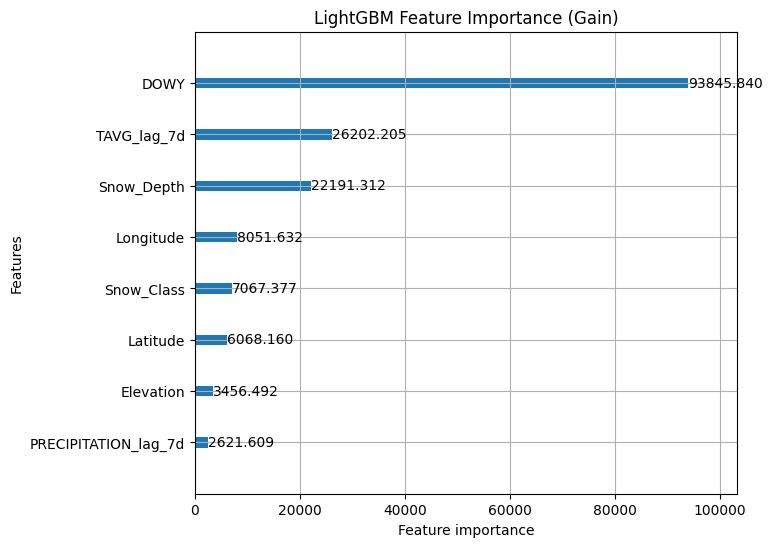

In [29]:
from matplotlib import pyplot as plt
# Plot feature importance using Split
lgb.plot_importance(lgbm_7, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

In [37]:
import shap

explainer_7 = shap.TreeExplainer(lgbm_7)
shap_values_7 = explainer_7(X_test_7d)

In [38]:
shap_df_7=pd.DataFrame(abs(shap_values_7.values), columns=lgbm_7.feature_name())

shap_df_7=shap_df_7.assign(Raw_snow_class = raw_data.x_val.Snow_Class.values)

shap_df_7 = shap_df_7.rename(columns={
        'Snow_Class': 'Snow Class',
        'Snow_Depth': 'Snow Depth',
        'TAVG_lag_7d': r'$\bar{t}_{-7}$',
        'PRECIPITATION_lag_7d': r'$\bar{p}_{-7}$'
    })

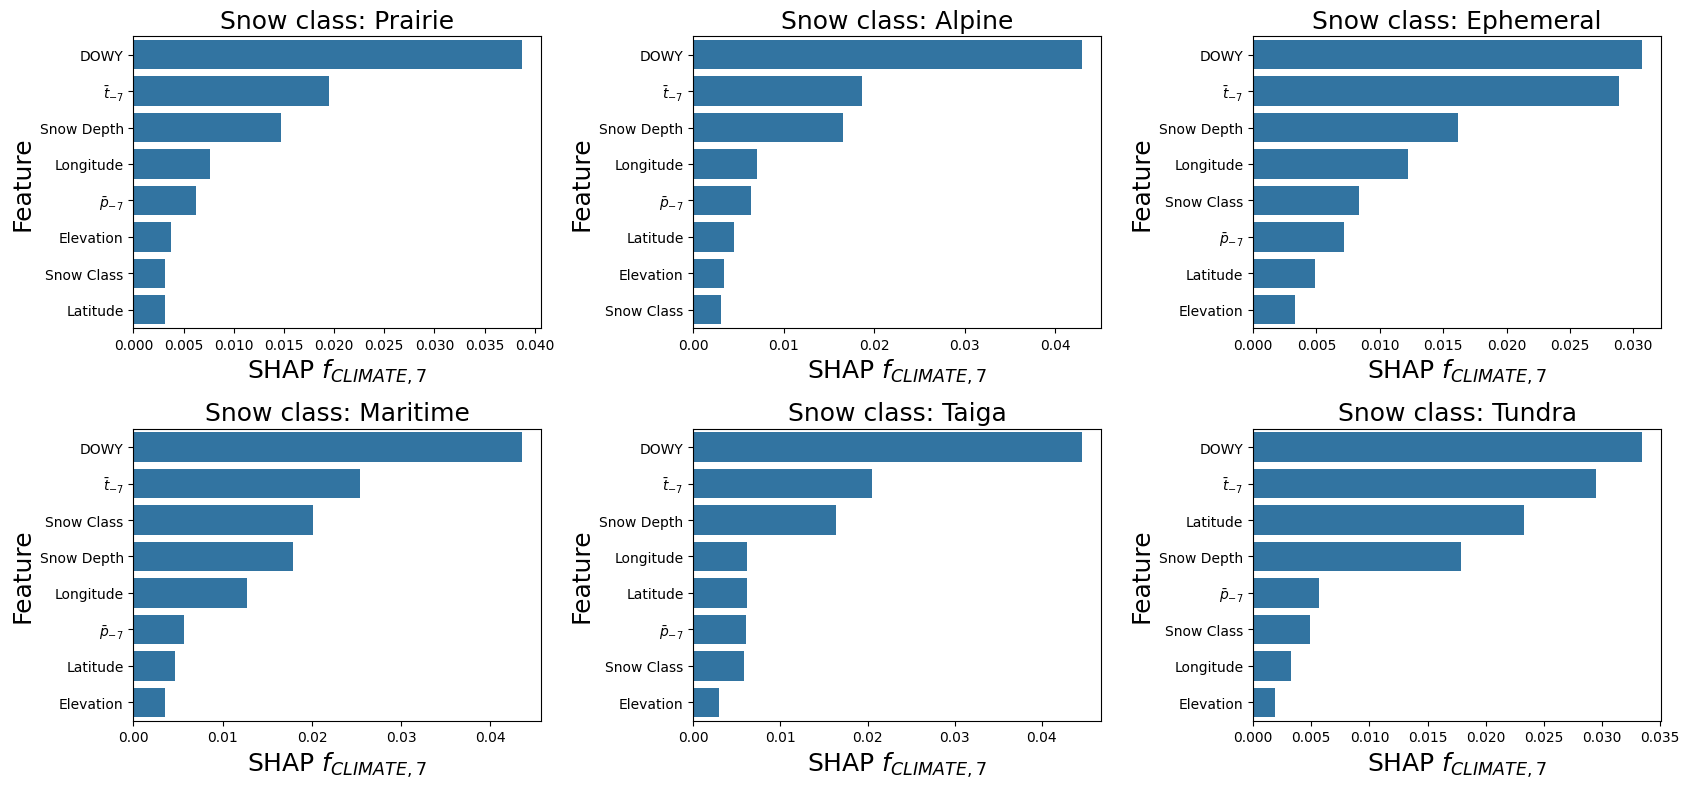

In [41]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(17, 8))
ax = ax.flatten()  # flatten the 2D array of axes into 1D

for i, sc in enumerate(shap_df_7.Raw_snow_class.unique()):
    current_class = (
        shap_df_7.query("Raw_snow_class == @sc")
        .drop('Raw_snow_class', axis=1)
        .mean()
        .sort_values(ascending=False)
        .to_frame()
        .reset_index()
        .rename(columns={'index': 'Feature', 0: 'Importance'})
    )
    
    sns.barplot(x="Importance", y="Feature", data=current_class, ax=ax[i])
    ax[i].set_title(f"Snow class: {sc}", fontsize=18)
    ax[i].set_xlabel("SHAP $f_{CLIMATE, 7}$", fontsize=18)
    ax[i].set_ylabel("Feature", fontsize=18)
    ax[i].tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('../plots/shap_by_class_clim_7.jpg', dpi=300, bbox_inches='tight')
plt.show()


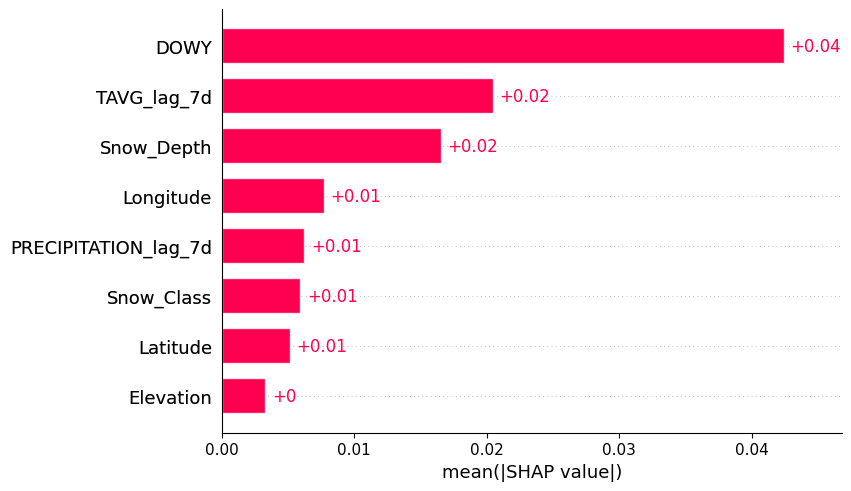

In [42]:
shap.plots.bar(shap_values_7)

In [45]:
# climate_swe_results=pd.DataFrame({
#     'True_SWE': raw_data.x_val.SWE.values,
#     'EXT_SWE_climate': climate_density_results.EXT_Density_climate.values*X_test_7d.Snow_Depth.values,
#     'RF_SWE_climate': climate_density_results.RF_Density_climate.values*X_test_7d.Snow_Depth.values,
#     'LGBM_SWE_climate': climate_density_results.LGBM_Density_climate.values*X_test_7d.Snow_Depth.values,
#     'XGB_SWE_climate': climate_density_results.XGB_Density_climate.values*X_test_7d.Snow_Depth.values,
# })

# climate_swe_results.head()

In [31]:
compare_multiple_models(climate_density_results, 'True_Density')

,EXT_Density_climate,RF_Density_climate,LGBM_Density_climate,XGB_Density_climate
RMSE,0.048647,0.049515,0.048000,0.048148
MBE,0.001702,0.001681,0.002265,0.002721
RSQ,0.715522,0.705277,0.723036,0.721324


In [32]:
compare_multiple_models(climate_swe_results, 'True_SWE')

,EXT_SWE_climate,RF_SWE_climate,LGBM_SWE_climate,XGB_SWE_climate
RMSE,5.063582,5.453277,5.028539,5.012549
MBE,0.123620,0.128247,0.212589,0.259325
RSQ,0.969696,0.964852,0.970114,0.970303


In [40]:
import seaborn as sns

In [54]:
shap_importance_main=(
    pd.DataFrame(
        data={
            "Feature": lgbm_main.feature_name(),
            "Importance": np.abs(shap_values.values).mean(axis=0)
        }
    )
    .sort_values(by="Importance", ascending=False)
    .replace({
        'Snow_Class': 'Snow Class',
        'Snow Depth': 'Snow Depth',
    })
)

shap_importance_main

,Feature,Importance
2,DOWY,0.052164
5,Snow Class,0.011241
1,Snow_Depth,0.011115
4,Longitude,0.010083
3,Latitude,0.006069
0,Elevation,0.003332


In [55]:
shap_importance_climate=(
    pd.DataFrame(
        data={
            "Feature": lgbm_7.feature_name(),
            "Importance": np.abs(shap_values_7.values).mean(axis=0)
        }
    )
    .sort_values(by="Importance", ascending=False)
    .replace({
        'Snow_Class': 'Snow Class',
        'Snow_Depth': 'Snow Depth',
        'TAVG_lag_7d': r'$\bar{t}_{-7}$',
        'PRECIPITATION_lag_7d': r'$\bar{p}_{-7}$'
    })
)

shap_importance_climate

,Feature,Importance
2,DOWY,0.042424
6,$\bar{t}_{-7}$,0.020452
1,Snow Depth,0.016546
4,Longitude,0.007714
5,$\bar{p}_{-7}$,0.006228
7,Snow Class,0.005936
3,Latitude,0.005120
0,Elevation,0.003299


In [56]:
splits = lgbm_main.feature_importance(importance_type='split')
gains = lgbm_main.feature_importance(importance_type='gain')
average_gain = np.divide(gains, splits, out=np.zeros_like(gains), where=splits!=0)

# Normalize to sum to 1
normalized_gain = average_gain / average_gain.sum()

xgboost_gain_main = (
    pd.DataFrame(
        data={
            "Feature": lgbm_main.feature_name(),
            "Importance": normalized_gain  # Use normalized values
        }
    )
    .sort_values(by="Importance", ascending=False)
    .replace({
        'Snow_Class': 'Snow Class',
        'Snow_Depth': 'Snow Depth',
    })
)

xgboost_gain_main

,Feature,Importance
2,DOWY,0.643154
5,Snow Class,0.239762
1,Snow Depth,0.059232
4,Longitude,0.024709
3,Latitude,0.020585
0,Elevation,0.012558


In [61]:
lgbm_7.feature_importance?

Signature:
lgbm_7.feature_importance(
    importance_type: str = 'split',
    iteration: Optional[int] = None,
) -> numpy.ndarray
Docstring:
Get feature importances.

Parameters
----------
importance_type : str, optional (default="split")
    How the importance is calculated.
    If "split", result contains numbers of times the feature is used in a model.
    If "gain", result contains total gains of splits which use the feature.
iteration : int or None, optional (default=None)
    Limit number of iterations in the feature importance calculation.
    If None, if the best iteration exists, it is used; otherwise, all trees are used.
    If <= 0, all trees are used (no limits).

Returns
-------
result : numpy array
    Array with feature importances.
File:      ~/miniconda3/envs/ml_density_env/lib/python3.11/site-packages/lightgbm/basic.py
Type:      method

In [57]:
splits_7 = lgbm_7.feature_importance(importance_type='split')
gains_7 = lgbm_7.feature_importance(importance_type='gain')
average_gain_7 = np.divide(gains_7, splits_7, out=np.zeros_like(gains_7), where=splits_7!=0)

normalized_gain_7 = average_gain_7 / average_gain_7.sum()

xgboost_gain_climate=(
    pd.DataFrame(
        data={
            "Feature": lgbm_7.feature_name(),
            "Importance": normalized_gain_7
        }
    )
    .sort_values(by="Importance", ascending=False)
    .replace({
        'Snow_Class': 'Snow Class',
        'Snow_Depth': 'Snow Depth',
        'TAVG_lag_7d': r'$\bar{t}_{-7}$',
        'PRECIPITATION_lag_7d': r'$\bar{p}_{-7}$'
    })
)

xgboost_gain_climate

,Feature,Importance
2,DOWY,0.503335
6,$\bar{t}_{-7}$,0.240735
7,Snow Class,0.112361
1,Snow Depth,0.074971
4,Longitude,0.021037
5,$\bar{p}_{-7}$,0.020279
3,Latitude,0.016232
0,Elevation,0.011050


In [58]:
from matplotlib.ticker import MultipleLocator

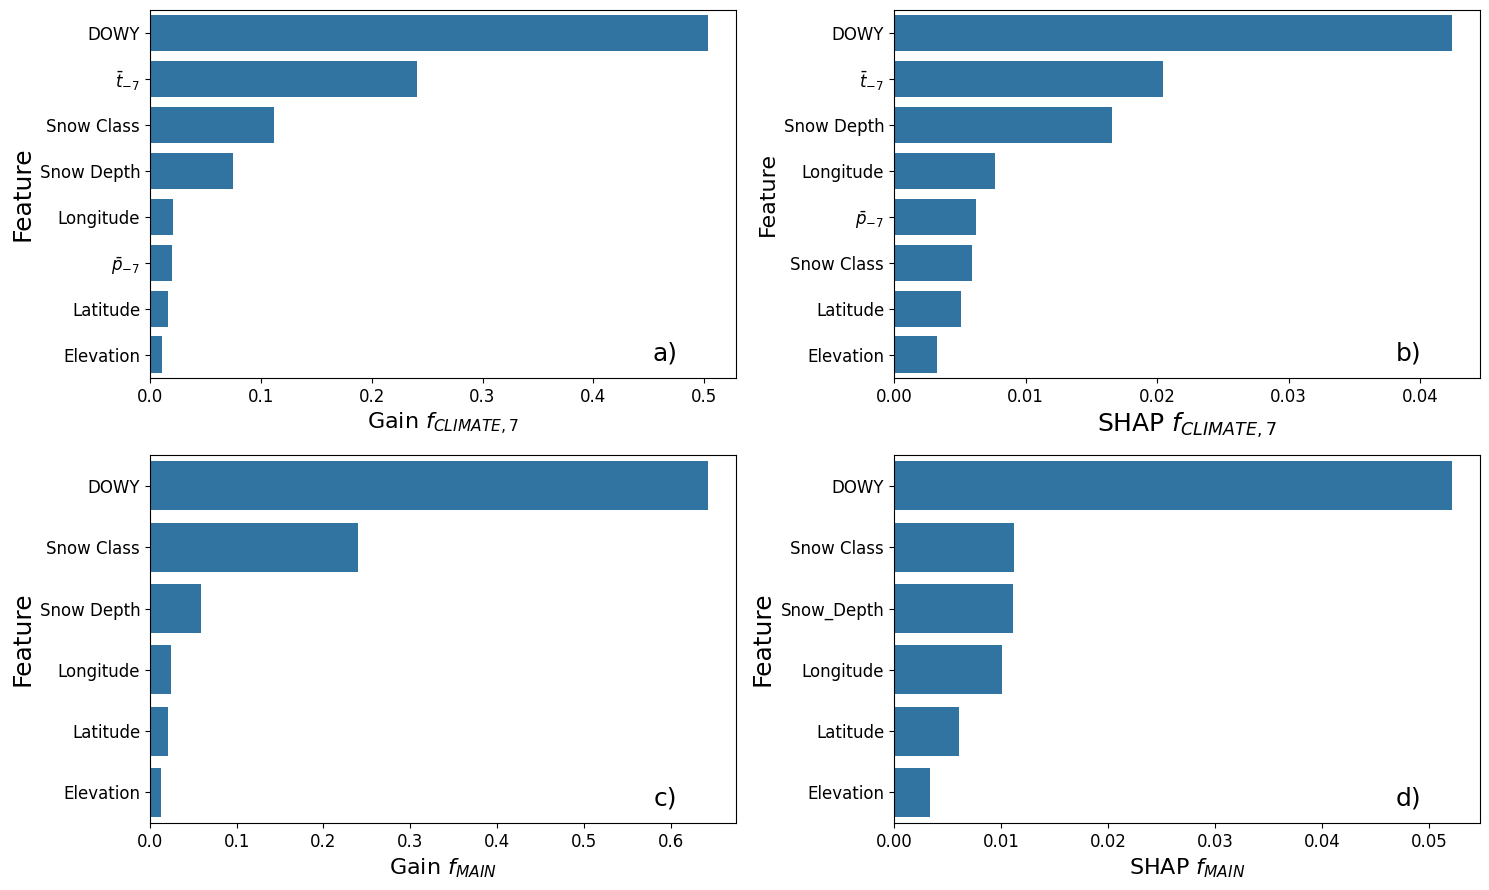

In [59]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 9))

sns.barplot(x="Importance", y="Feature", data=xgboost_gain_climate, ax=ax[0, 0])
ax[0, 0].set_xlabel("Gain $f_{CLIMATE, 7}$", fontsize=16)
ax[0, 0].set_ylabel("Feature", fontsize=18)
ax[0, 0].tick_params(labelsize=12)
ax[0, 0].text(0.90, 0.10, 'a)', transform=ax[0, 0].transAxes, fontsize=18, va='top', ha='right')



sns.barplot(x="Importance", y="Feature", data=shap_importance_climate, ax=ax[0, 1])
ax[0, 1].set_xlabel("SHAP $f_{CLIMATE, 7}$", fontsize=18)
ax[0, 1].set_ylabel("Feature", fontsize=16)
ax[0, 1].tick_params(labelsize=12)
ax[0, 1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0, 1].text(0.90, 0.10, 'b)', transform=ax[0, 1].transAxes, fontsize=18, va='top', ha='right')



sns.barplot(x="Importance", y="Feature", data=xgboost_gain_main, ax=ax[1, 0])
ax[1, 0].set_xlabel("Gain $f_{MAIN}$", fontsize=16)
ax[1, 0].set_ylabel("Feature", fontsize=18)
ax[1, 0].tick_params(labelsize=12)
ax[1, 0].text(0.90, 0.10, 'c)', transform=ax[1, 0].transAxes, fontsize=18, va='top', ha='right')



sns.barplot(x="Importance", y="Feature", data=shap_importance_main, ax=ax[1, 1])
ax[1, 1].set_xlabel("SHAP $f_{MAIN}$", fontsize=16)
ax[1, 1].set_ylabel("Feature", fontsize=18)
ax[1, 1].tick_params(labelsize=12)
ax[1, 1].text(0.90, 0.10, 'd)', transform=ax[1, 1].transAxes, fontsize=18, va='top', ha='right')

plt.tight_layout()
plt.savefig('../plots/figure10.jpg', dpi=300, bbox_inches='tight')
plt.show()

## Climate 14

### LightGBM Wins!

We'll save the model weights and encoder for later use.

In [25]:
if not os.path.exists('../ML_weights'):
    os.makedirs('../ML_weights')
else:
    print('Folder already exists')

Folder already exists


In [26]:
xgb_main.save_model("../ML_weights/main_density_model.ubj") # Non climate
xgb_climate.save_model("../ML_weights/climate_density_model.ubj") # Climate Enhanced

In [27]:
# Save the encoders to a file
with open('../ML_weights/encoder_climate.pkl', 'wb') as f:
    pickle.dump(encoder_climate, f)

with open('../ML_weights/encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

### Store Predictions

In [33]:
main_model_results.drop('True_Density', axis=1).to_parquet('../results/density/ML_models_predictions_baseline.parquet', index=False, compression='gzip')
main_model_swe_results.drop('True_SWE', axis=1).to_parquet('../results/swe/ML_models_predictions_baseline.parquet', index=False, compression='gzip')

In [34]:
climate_density_results.drop('True_Density', axis=1).to_parquet('../results/density/ML_models_predictions_climate.parquet', index=True, compression='gzip')
climate_swe_results.drop('True_SWE', axis=1).to_parquet('../results/swe/ML_models_predictions_climate.parquet', index=True, compression='gzip')

# The End!